# Social Contagion

In [17]:
from IPython.display import Markdown, display
import nbformat, re

NOTEBOOK_PATH = "project_v2.ipynb"

def anchor(s):
    return re.sub(r'[^0-9a-zA-Z]+', '-', s.strip()).strip('-').lower()

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

lines = ["# Table of Contents", ""]

# Track section numbers at each level (now for h2-h6)
counters = [0, 0, 0, 0, 0]  # support h2 through h6

for cell in nb.cells:
    if cell.get("cell_type") == "markdown":
        for line in cell["source"].splitlines():
            m = re.match(r'^(#{1,6})\s+(.+?)\s*$', line)
            if not m: 
                continue
            level = len(m.group(1))
            text = m.group(2).strip()
            
            # Skip h1 (single #) entirely
            if level == 1:
                continue
            
            # Adjust level: h2 becomes 0, h3 becomes 1, etc.
            adjusted_level = level - 2
            
            # Increment current level, reset deeper levels
            counters[adjusted_level] += 1
            for i in range(adjusted_level + 1, 5):
                counters[i] = 0
            
            # Build section number (e.g., "1", "1.1", "1.1.2")
            num = '.'.join(str(counters[i]) for i in range(adjusted_level + 1))
            
            # Format with indentation (h2 has no indent, h3 has 2 spaces, etc.)
            indent = "  " * adjusted_level
            lines.append(f'{indent}- {num}. [{text}](#{anchor(text)})')

display(Markdown("\n".join(lines)))

# Table of Contents

- 1. [Learning goals](#learning-goals)
- 2. [Setup](#setup)
- 3. [What is Contagion?](#what-is-contagion)
  - 3.1. [Real-world examples](#real-world-examples)
  - 3.2. [Why we care](#why-we-care)
  - 3.3. [3.3 Cross-domain examples of social contagion](#3-3-cross-domain-examples-of-social-contagion)
- 4. [Overview of Contagion Models](#overview-of-contagion-models)
  - 4.1. [Simple contagion](#simple-contagion)
  - 4.2. [Complex contagion](#complex-contagion)
  - 4.3. [Simple vs. complex contagion: what changes?](#simple-vs-complex-contagion-what-changes)
- 5. [Models & Implementation](#models-implementation)
  - 5.1. [Independent Cascade (IC) Model](#independent-cascade-ic-model)
  - 5.2. [Watts Threshold Model (WTM)](#watts-threshold-model-wtm)
  - 5.3. [Toy example: belief updating and simple vs. complex contagion](#toy-example-belief-updating-and-simple-vs-complex-contagion)
    - 5.3.1. [Simple contagion version](#simple-contagion-version)
    - 5.3.2. [Complex contagion version](#complex-contagion-version)
    - 5.3.3. [Connection to conspiracy theories and misinformation](#connection-to-conspiracy-theories-and-misinformation)
  - 5.4. [Your Turn](#your-turn)
- 6. [How Structure Shapes Cascades](#how-structure-shapes-cascades)
  - 6.1. [Your Turn](#your-turn)
  - 6.2. [Your Turn](#your-turn)
  - 6.3. [A Question for practice](#a-question-for-practice)
    - 6.3.1. [ER](#er)
    - 6.3.2. [BA](#ba)
    - 6.3.3. [WS](#ws)
    - 6.3.4. [GN & SBM](#gn-sbm)
    - 6.3.5. [RG (Random Geometric)](#rg-random-geometric)
- 7. [Thresholds, Heterogeneity, and Adoption Dynamics](#thresholds-heterogeneity-and-adoption-dynamics)
- 8. [Other Extensions and Advanced Topics:](#other-extensions-and-advanced-topics)
  - 8.1. [Contagion on Directed/Weighted Networks](#contagion-on-directed-weighted-networks)
  - 8.2. [Contagion Beyond Networks: Spatial, Agent-Based, and Hybrid Models](#contagion-beyond-networks-spatial-agent-based-and-hybrid-models)
  - 8.3. [Advanced Visualization and Animation](#advanced-visualization-and-animation)
  - 8.4. [Social Contagion in LLMs](#social-contagion-in-llms)
  - 8.5. [Causal Identification: Contagion vs Homophily](#causal-identification-contagion-vs-homophily)
- 9. [Influence Maximization and Seeding Strategies](#influence-maximization-and-seeding-strategies)
- 10. [References](#references)
- 11. [Useful Links](#useful-links)
- 12. [Supplementary Materials: Competing Contagions and Interference](#supplementary-materials-competing-contagions-and-interference)

## Learning goals
- Understand contagion, and why it matters.
- Distinguish between simple and complex contagion.
- Implement canonical models of social contagion.
- Analyze how network structure shapes contagion dynamics.
- Explore strategies for seeding and controlling contagion.
- Connect simulations to analytical insights.
- Connect models to empirical findings and case studies across domains (health, technology adoption, marketing, etc.).
- Extend models to more realistic settings.
- Visualize contagion processes.


## Setup


In [47]:
# Core scientific stack
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from collections import deque
from dataclasses import dataclass
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Union, Set

# Reproducibility
rng = np.random.default_rng(42)

# Matplotlib defaults (no explicit color choices per course tooling conventions)
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.grid'] = True

# Helper to silence warnings in demos if needed
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)



## What is Contagion?

**Contagion** refers to the spread of behaviors, ideas, or diseases through networks. It encompasses various processes, including:
- **Epidemics**: Spread of infectious diseases (e.g., flu, COVID-19).
- **Information diffusion**: Spread of news, rumors, or innovations.
- **Behavioral adoption**: Spread of behaviors like smoking, exercise, or technology use.
- **Emotional contagion**: Spread of emotions like happiness or fear.

### Real-world examples
Yawning, the spread of panic in a crowd, the adoption of fashion trends, the phenomenon of viral online challenges like the ALS Ice Bucket Challenge, and the rapid dissemination of information (or misinformation) on social media platforms, are all examples of contagion in action.

### Why we care
We have a vested interest in understanding contagion because it affects public health, marketing strategies, social movements, and more. By studying contagion, we can design better interventions to promote beneficial behaviors and curb harmful ones. In most social contexts, there are multiple competing contagions (e.g., health behaviors, political ideologies), and policy makers need to understand how to promote or inhibit specific contagions with limited resources.

Also, sometimes, contagion can lead to unintended consequences, such as the spread of misinformation or panic. We need to understand these dynamics to mitigate negative outcomes.

Most of businesses are also interested in understanding contagion to optimize marketing strategies, enhance customer engagement, and drive product adoption. By leveraging insights from contagion models, businesses can create more effective campaigns that resonate with their target audience.

### 3.3 Cross-domain examples of social contagion

To emphasize how general these ideas are, here are a few stylized examples that map onto the simple / complex contagion distinction:

1. **Epidemiology (simple contagion-ish)**  
   - A respiratory virus on a contact network. One infectious contact can be enough for transmission.  
   - Long-range airline edges and hubs (airports, schools) dramatically accelerate global spread.

2. **Electric vehicle (EV) or smartphone adoption (often complex)**  
   - You might need *several* friends or neighbors to adopt before you are convinced the technology is reliable, that charging / ecosystem infrastructure exists, and that the social risk is low.  
   - Local clustering (neighbors observing each other’s cars or phones) and visible infrastructure (chargers, Apple stores) create reinforcement.

3. **Fax machines and other network goods (classic coordination example)**  
   - A fax machine (or, more modernly, a messaging app or payment network) is only useful if *enough* of your contacts also have it.  
   - Adoption is highly dependent on reaching a critical mass; below the critical mass, individuals may want to adopt but hold back.

4. **Marketing and word-of-mouth campaigns**  
   - “Tell three friends” campaigns try to turn early adopters into seeds in the network.  
   - For low-cost products, a single enthusiastic friend may be enough (simple contagion); for more expensive or identity-relevant products, people may wait for multiple endorsements (complex contagion).

5. **Online information and (mis)information spreading**  
   - A random meme can spread with single exposures, but belief in a conspiracy theory or strong political narrative often requires repeated, mutually reinforcing exposures from similar peers or tightly knit communities.  
   - Highly clustered, homophilous communities can therefore be especially prone to certain kinds of misinformation cascades.

We will refer back to these examples when interpreting simulation results in later sections.


## Overview of Contagion Models

We will use **contagion** as an umbrella term for any process where a state (infected / adopted / believing / activated) can spread through a network.

A classic and very useful distinction is between **simple** and **complex** contagion.

### Simple contagion

- **Definition**: A *single effective exposure* can be enough to trigger adoption.
- **Canonical models**: SI / SIR epidemic models, and the **Independent Cascade (IC)** model.
- **Dynamics** (IC model intuition):
  - When a node adopts, it gets one chance to activate each susceptible neighbor with probability \(p\).
  - Exposures are independent across edges.
- **Network effects** (typical findings):
  - Long ties and shortcuts tend to **accelerate** spread.
  - Clustering can **slow** spread because many exposures are redundant.
  - Degree heterogeneity can create **super-spreaders**.

- **Examples**:
  - Biological infections with relatively high transmissibility.
  - “One-click” information forwarding (retweets, reshares).
  - Low-commitment behaviors (liking a post, clicking a link).

**Some references**

- Pastor-Satorras et al. (2015) – epidemic processes on networks.
- Dodds & Watts (2004) – generalized contagion model that interpolates between epidemic-like and more complex behavior.
- Hodas & Lerman (2014) – simple behavioral contagion in online information.

### Complex contagion

- **Definition**: Adoption requires **reinforcement** from multiple neighbors, repeated exposures, or higher-order group interactions.
- **Canonical models**:
  - **Watts Threshold Model (WTM)**: node adopts if the *fraction* of adopted neighbors exceeds a threshold \(\phi_i\).
  - **\(k\)-threshold** variants: node adopts if at least \(k_i\) neighbors adopt.
  - **High-order / simplicial contagion**: adoption may require activation of entire groups (e.g., 3-cliques) rather than just individual neighbors.

- **Network effects** (typical findings):
  - Long ties and weak connections can **hinder** spread because they bypass reinforcement in local clusters.
  - Strong clustering and community structure can **enable** cascades by providing repeated, independent confirmations.
  - Heterogeneous thresholds can create tipping points and partial cascades.

- **Examples**:
  - Costly behavior change (smoking cessation, exercise regimes).
  - Participation in risky protests or strikes.
  - Adopting an unfamiliar technology when friends need to coordinate (e.g., messaging apps, EV ownership, or collaborative tools).

**Some references**

- Granovetter (1978) – threshold models of collective behavior.
- Watts (2002) – random-network cascades in threshold models.
- Centola & Macy (2007) – *complex contagions and the weakness of long ties*.
- Centola (2010) – experimental evidence that clustering promotes adoption of health behaviors.
- Iacopini et al. (2019) – *Simplicial models of social contagion* (higher-order, group-based reinforcement).
- Airoldi & Christakis (2024), Christakis & Fowler (2007–2013) – empirical claims and experiments on social contagion in health behaviors, with ongoing debates about identification vs. homophily.

### Simple vs. complex contagion: what changes?

Across this notebook we will repeatedly come back to:

- **Update rule**: does a single neighbor suffice, or do we require reinforcement and/or higher-order groups?
- **Thresholds**: are they the same for everyone, or heterogeneous across the population?
- **Network structure**: how do degree distribution, clustering, and community structure shape cascade size and speed?

> **Note for future extensions.** A natural upgrade to this section would be to include *side-by-side* replication plots from a major paper (for example, cascade-size distributions from Watts (2002) or adoption curves from Centola’s 2010 experiment, using either provided code or publicly available summary statistics). We do **not** implement that here to keep the notebook lightweight, but the rest of the notebook is written so that such replications could be plugged in later.

- For a recent example of how higher-order, threshold-like contagion dynamics can induce an *effective direction* of spread even on undirected graphs, see the preprint *Emergent Directedness in Social Contagion* (2025).

## Models & Implementation

### Independent Cascade (IC) Model

In [20]:

@dataclass
class CascadeResult:
    adopted: Set
    history: List[Set]
    adopters_by_t: List[int]
    exposures: Dict # node -> number of received attempts (IC) or neighbor counts (WTM)
    steps: int
def choose_seeds(G: nx.Graph, k: int, method: str = "random", rng: Optional[np.random.Generator] = None) -> List:
    """Pick k seed nodes by a given strategy.
    
    method in {"random", "degree", "kcore"}.
    """
    rng = rng or np.random.default_rng()
    nodes = list(G.nodes())
    if k <= 0:
        return []
    if method == "random":
        return list(rng.choice(nodes, size=min(k, len(nodes)), replace=False))
    elif method == "degree":
        return [n for n,_ in sorted(G.degree(), key=lambda t: t[1], reverse=True)[:k]]
    elif method == "kcore":
        kc = nx.core_number(G)
        return [n for n,_ in sorted(kc.items(), key=lambda t: t[1], reverse=True)[:k]]
    else:
        raise ValueError(f"Unknown seeding method: {method}")


In [21]:

def simulate_ic(
    G: nx.Graph,
    seeds: Iterable,
    p: float = 0.1,
    max_steps: Optional[int] = None,
    rng: Optional[np.random.Generator] = None,
) -> CascadeResult:
    """Independent Cascade (IC) model.
    
    Parameters
    ----------
    G : nx.Graph
    seeds : iterable of seed nodes
    p : float in [0,1], activation prob along each edge (one attempt per newly adopted neighbor)
    max_steps : optional step cap
    rng : numpy Generator
    
    Returns
    -------
    CascadeResult with adopted set, history (set per t), adopters_by_t (counts), exposures, steps
    """
    rng = rng or np.random.default_rng()
    adopted = set(seeds)
    frontier = set(seeds)  # newly adopted at current t
    history = [set(frontier)]
    adopters_by_t = [len(frontier)]
    exposures = {n: 0 for n in G.nodes()}  # number of *attempts* received
    
    steps = 0
    while frontier and (max_steps is None or steps < max_steps):
        steps += 1
        new_frontier = set()
        for u in frontier:
            for v in G.neighbors(u):
                if v in adopted:
                    continue
                exposures[v] = exposures.get(v, 0) + 1
                if rng.random() < p:
                    adopted.add(v)
                    new_frontier.add(v)
        if not new_frontier:
            break
        history.append(set(new_frontier))
        adopters_by_t.append(len(new_frontier))
        frontier = new_frontier
    return CascadeResult(adopted=adopted, history=history, adopters_by_t=adopters_by_t, exposures=exposures, steps=steps)


### Watts Threshold Model (WTM)

In [22]:

def _resolve_thresholds(G: nx.Graph, phi: Union[float, Dict, Callable, Sequence], rng: Optional[np.random.Generator] = None) -> Dict:
    """Return dict of node->threshold in [0,1].
    - float: constant
    - dict: per-node
    - callable: called per node to sample threshold
    - sequence: aligned in order of G.nodes()
    """
    rng = rng or np.random.default_rng()
    nodes = list(G.nodes())
    if isinstance(phi, (float, int)):
        return {n: float(phi) for n in nodes}
    if isinstance(phi, dict):
        # default to 1.1 (impossible) if missing, ensuring explicitness
        return {n: float(phi.get(n, 1.1)) for n in nodes}
    if callable(phi):
        return {n: float(phi(n, G, rng)) for n in nodes}
    # sequence-like
    arr = list(map(float, phi))
    if len(arr) != len(nodes):
        raise ValueError("Length of phi sequence must equal number of nodes")
    return {n: arr[i] for i, n in enumerate(nodes)}

def simulate_wtm(
    G: nx.Graph,
    seeds: Iterable,
    phi: Union[float, Dict, Callable, Sequence] = 0.2,
    synchronous: bool = True,
    max_steps: Optional[int] = None,
    rng: Optional[np.random.Generator] = None,
) -> CascadeResult:
    """Watts Threshold Model (WTM) / fractional threshold complex contagion.
    
    Parameters
    ----------
    G : nx.Graph
    seeds : iterable of seed nodes
    phi : threshold spec (float, dict, callable, or sequence). Fraction of neighbors required.
    synchronous : if True, update in rounds; otherwise adopt as soon as threshold satisfied in a wave
    max_steps : optional step cap
    rng : numpy Generator
    """
    rng = rng or np.random.default_rng()
    thresholds = _resolve_thresholds(G, phi, rng=rng)
    adopted = set(seeds)
    history = [set(adopted)]
    adopters_by_t = [len(adopted)]
    steps = 0
    # track neighbor counts for introspection
    exposures = {n: 0 for n in G.nodes()}  # here we store current number of adopted neighbors
    
    def fraction_adopted_neighbors(v):
        k = G.degree(v)
        if k == 0:
            return 0.0
        a = sum((1 for u in G.neighbors(v) if u in adopted))
        exposures[v] = a  # store raw count
        return a / k
    
    while True and (max_steps is None or steps < max_steps):
        steps += 1
        if synchronous:
            new_adopters = {v for v in G.nodes() if v not in adopted and fraction_adopted_neighbors(v) >= thresholds[v]}
        else:
            # asynchronous "wave": scan in random order
            new_adopters = set()
            for v in rng.permutation(list(G.nodes())):
                if v in adopted or v in new_adopters:
                    continue
                if fraction_adopted_neighbors(v) >= thresholds[v]:
                    new_adopters.add(v)
                    adopted.add(v)  # immediate reinforcement effect
        if not new_adopters:
            break
        adopted |= new_adopters
        history.append(set(new_adopters))
        adopters_by_t.append(len(new_adopters))
    return CascadeResult(adopted=adopted, history=history, adopters_by_t=adopters_by_t, exposures=exposures, steps=steps)


In [23]:

def make_graph(kind: str = "ER", n: int = 200, avg_k: float = 6, rng: Optional[np.random.Generator] = None) -> nx.Graph:
    """Convenience graph factory for demos: ER, WS, BA.
    avg_k is interpreted per model.
    """
    rng = rng or np.random.default_rng()
    if kind.upper() == "ER":
        p = avg_k / (n-1)
        return nx.erdos_renyi_graph(n, p, seed=rng)
    if kind.upper() == "WS":
        k = int(round(avg_k))
        k = k + (k % 2)  # ensure even
        # beta (rewiring prob) exposed in wrapper below
        return nx.watts_strogatz_graph(n, k, 0.1, seed=rng)  # default beta=0.1
    if kind.upper() == "BA":
        m = max(1, int(round(avg_k/2)))
        return nx.barabasi_albert_graph(n, m, seed=rng)
    raise ValueError("kind must be one of {'ER','WS','BA'}")

def run_many_ic(G, seeds, ps: Sequence[float], runs_per_p: int = 20, rng: Optional[np.random.Generator] = None) -> pd.DataFrame:
    rng = rng or np.random.default_rng()
    rows = []
    for p in ps:
        for r in range(runs_per_p):
            res = simulate_ic(G, seeds=seeds, p=p, rng=rng)
            rows.append(dict(model="IC", p=p, run=r, final_frac=len(res.adopted)/G.number_of_nodes(), steps=res.steps))
    return pd.DataFrame(rows)

def run_many_wtm(G, seeds, phis: Sequence[float], runs_per_phi: int = 1, rng: Optional[np.random.Generator] = None) -> pd.DataFrame:
    rng = rng or np.random.default_rng()
    rows = []
    for phi in phis:
        for r in range(runs_per_phi):
            res = simulate_wtm(G, seeds=seeds, phi=phi, rng=rng)
            rows.append(dict(model="WTM", phi=phi, run=r, final_frac=len(res.adopted)/G.number_of_nodes(), steps=res.steps))
    return pd.DataFrame(rows)

def plot_sweep(df: pd.DataFrame, x: str, y: str = "final_frac", xlabel: str = "", ylabel: str = "Final adoption"):
    ax = df.groupby(x)[y].mean().plot(marker="o", lw=1)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0,1)
    plt.show()


IC: final adoption 9/200 in 3 steps
WTM: final adoption 200/200 in 8 steps


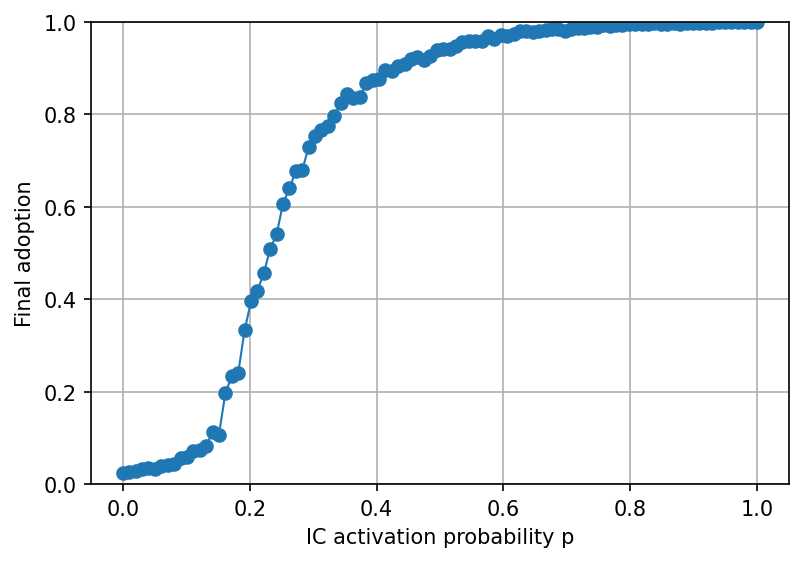

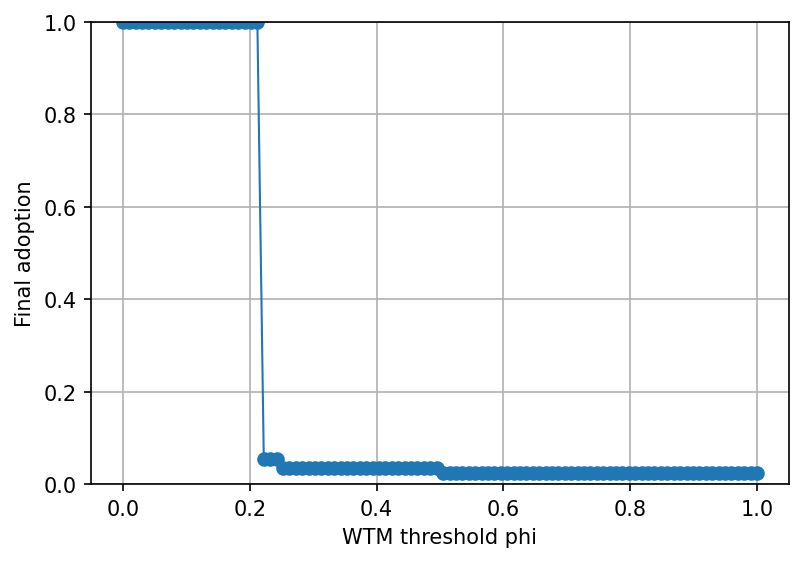

In [31]:
# run codes above

# Example usage
G = make_graph("ER", n=200, avg_k=6, rng=rng)
seeds = choose_seeds(G, k=5, method="random", rng=rng)
ic_res = simulate_ic(G, seeds=seeds, p=0.1, rng=rng)
wtm_res = simulate_wtm(G, seeds=seeds, phi=0.2, rng=rng)

# compare results
print(f"IC: final adoption {len(ic_res.adopted)}/{G.number_of_nodes()} in {ic_res.steps} steps")
print(f"WTM: final adoption {len(wtm_res.adopted)}/{G.number_of_nodes()} in {wtm_res.steps} steps")

# plot them using plot_sweep function above
ps = np.linspace(0, 1, 100)
phis = np.linspace(0, 1, 100)
ic_df = run_many_ic(G, seeds, ps, runs_per_p=20, rng=rng)
wtm_df = run_many_wtm(G, seeds, phis, runs_per_phi=5, rng=rng)
combined_df = pd.concat([ic_df, wtm_df], ignore_index=True)
plot_sweep(combined_df[combined_df['model'] == 'IC'], x='p', xlabel='IC activation probability p')
plot_sweep(combined_df[combined_df['model'] == 'WTM'], x='phi', xlabel='WTM threshold phi')


As expected, we see that in the IC model, the final adoption rate increases smoothly with the transmission probability \(p\). In contrast, the WTM exhibits a more abrupt transition in adoption rates as the threshold \(\phi\) decreases, highlighting the critical role of reinforcement in complex contagion processes.

### Toy example: belief updating and simple vs. complex contagion

To make the difference between simple and complex contagion concrete, consider a toy "belief" model.

- Each node $i$ in a network has a belief value $b_i(t) \in [0,100]$.
- Most nodes start at $b_i(0) = 0$.
- A small number of "zealot" or "seed" nodes start at $b_i(0) = 100$ and **stay there** (they are extremely convincing and never change their mind).

We then let beliefs update over time based on neighbors' beliefs.

#### Simple contagion version

At each discrete time step:

- Every non-zealot node looks at the **average belief of its neighbors**, $\bar{b}_{N(i)}(t)$.
- It moves part-way toward this average:
  $$
  b_i(t+1) = (1-\alpha)\,b_i(t) + \alpha\,\bar{b}_{N(i)}(t),
  $$
  where $0 < \alpha \le 1$ is a learning rate.

If the network is connected and the zealots keep broadcasting their belief of 100, eventually everyone's belief drifts upward toward 100. This is an analogue of **simple contagion**: *any* exposure to high-belief neighbors nudges you in that direction.

#### Complex contagion version

Now suppose people only update when **enough** of their neighbors already have high belief.

- Let $\theta$ be a **fraction-of-neighbors threshold** (e.g., $\theta = 0.3$).
- A node checks what fraction of its neighbors have $b_j(t) \ge B_{\text{high}}$ (e.g., $B_{\text{high}}=80$).
- Only if that fraction is at least $\theta$ does the node move toward the neighbor average; otherwise it keeps its current belief.

This produces behavior much closer to **complex contagion**:

- Single, isolated exposures to the "belief 100" zealots are often not enough.
- Beliefs jump once enough neighbors cross a critical level.

We can play with:

- the **threshold** $\theta$,
- the **learning rate** $\alpha$,
- and **which nodes** are zealots,

and observe how the network structure (e.g., hubs, clustering, community boundaries) changes whether the high belief cascades through the graph.

#### Connection to conspiracy theories and misinformation

This toy model is intentionally simple, but it captures several mechanisms that have been discussed in the literature on misinformation and conspiracy beliefs:

- People often need **multiple confirming signals** from similar others before trusting extreme claims (complex contagion).
- **Highly clustered, homophilous communities** are more likely to reach high internal agreement, even if the broader network never adopts the belief.
- **Bridging nodes** (people who belong to multiple communities) can transmit beliefs across groups, but only if they themselves cross their threshold.
- **Zealots / influencers** with high degree or centrality can start cascades, but their impact depends strongly on the surrounding structure.

In the code cell below, you can experiment with simple vs. complex belief updating on different network topologies.

/var/folders/nw/_gc7dkbx2gx_j7xr0bxs1x4h0000gn/T/ipykernel_37210/1004858722.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


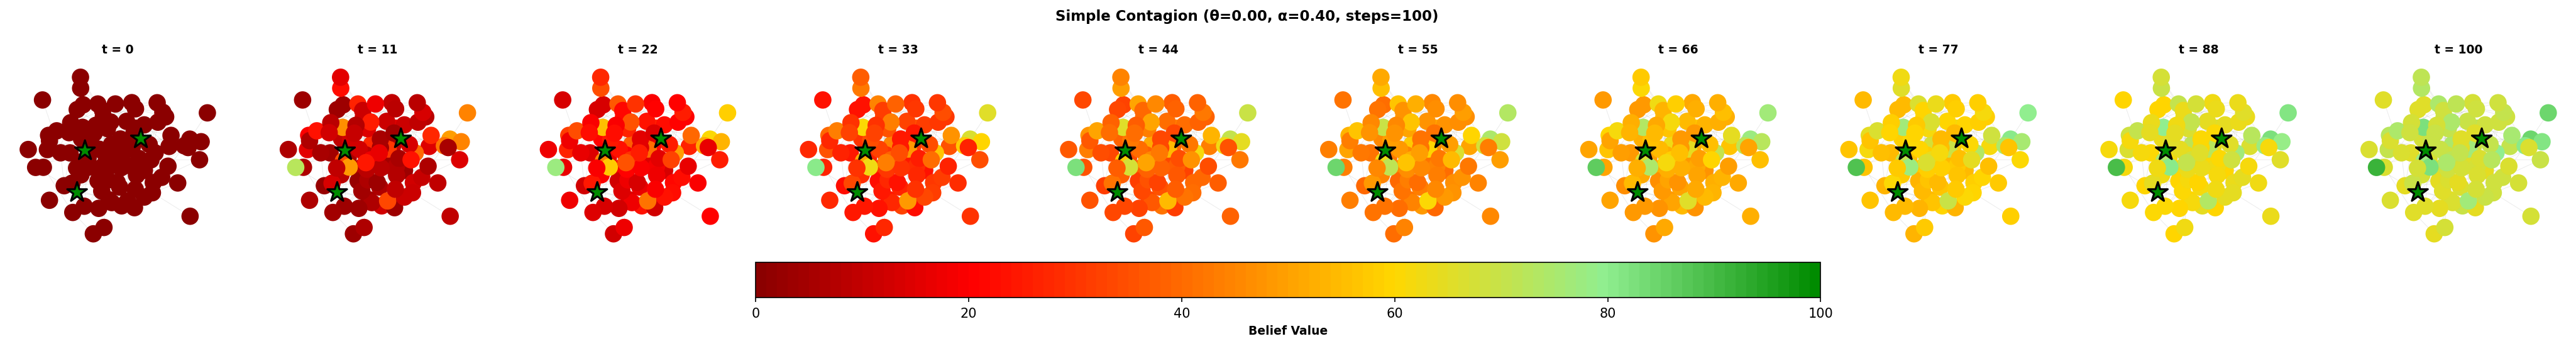

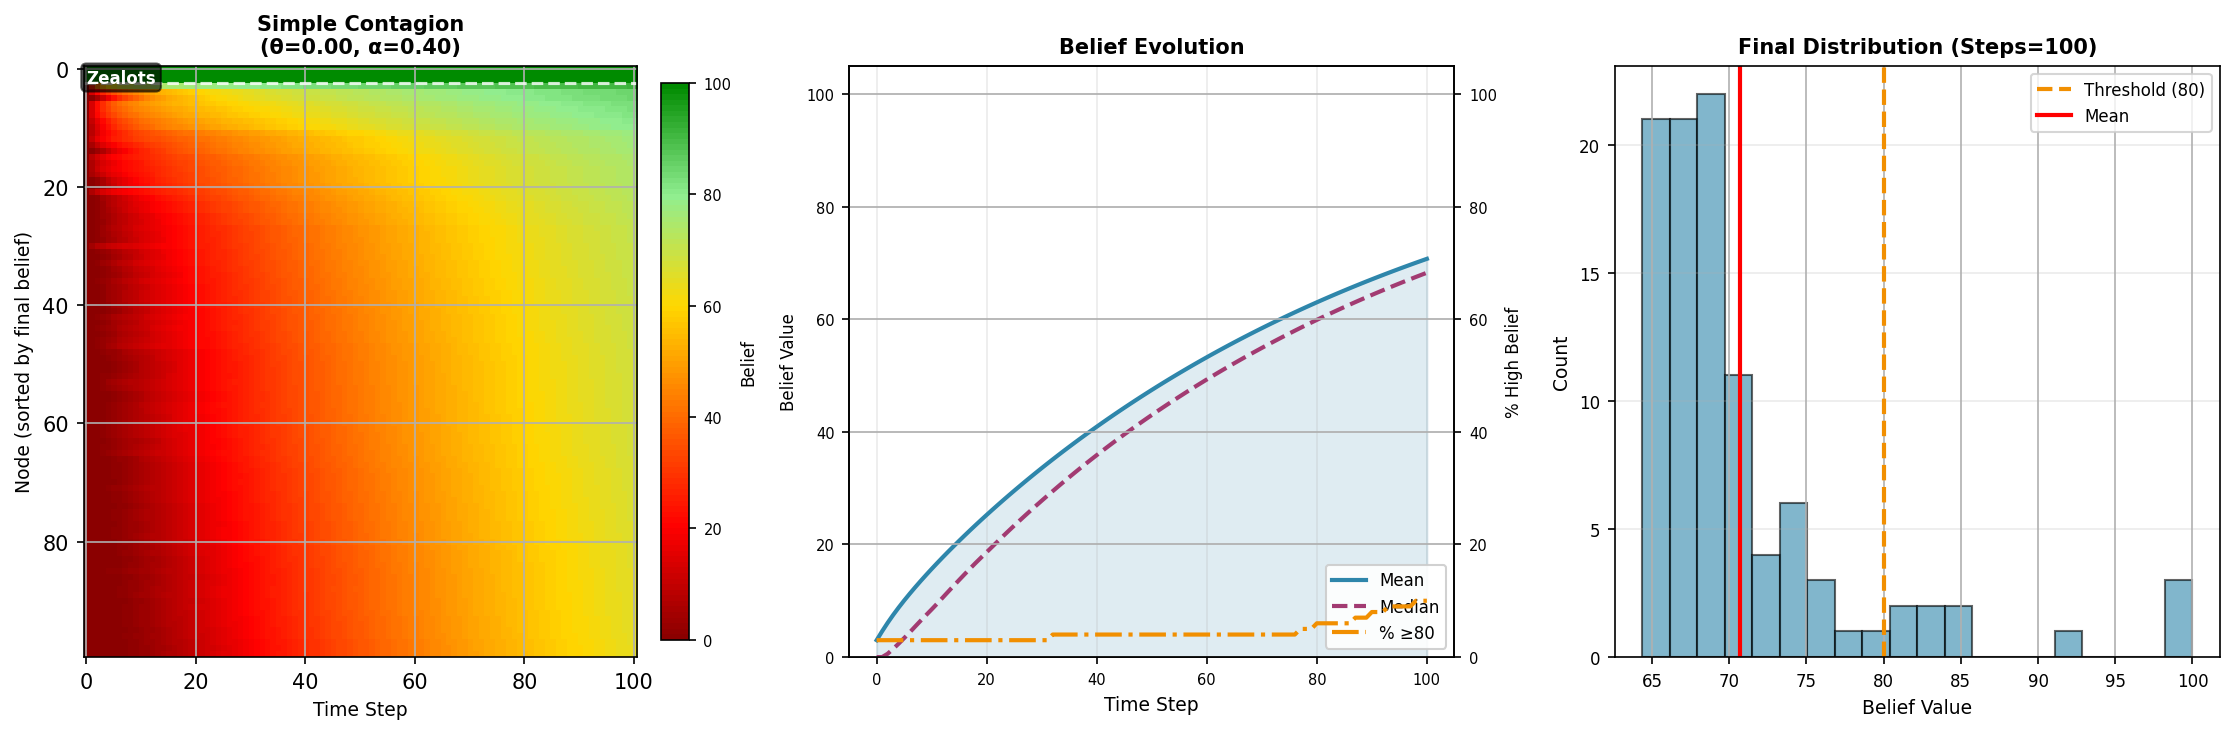

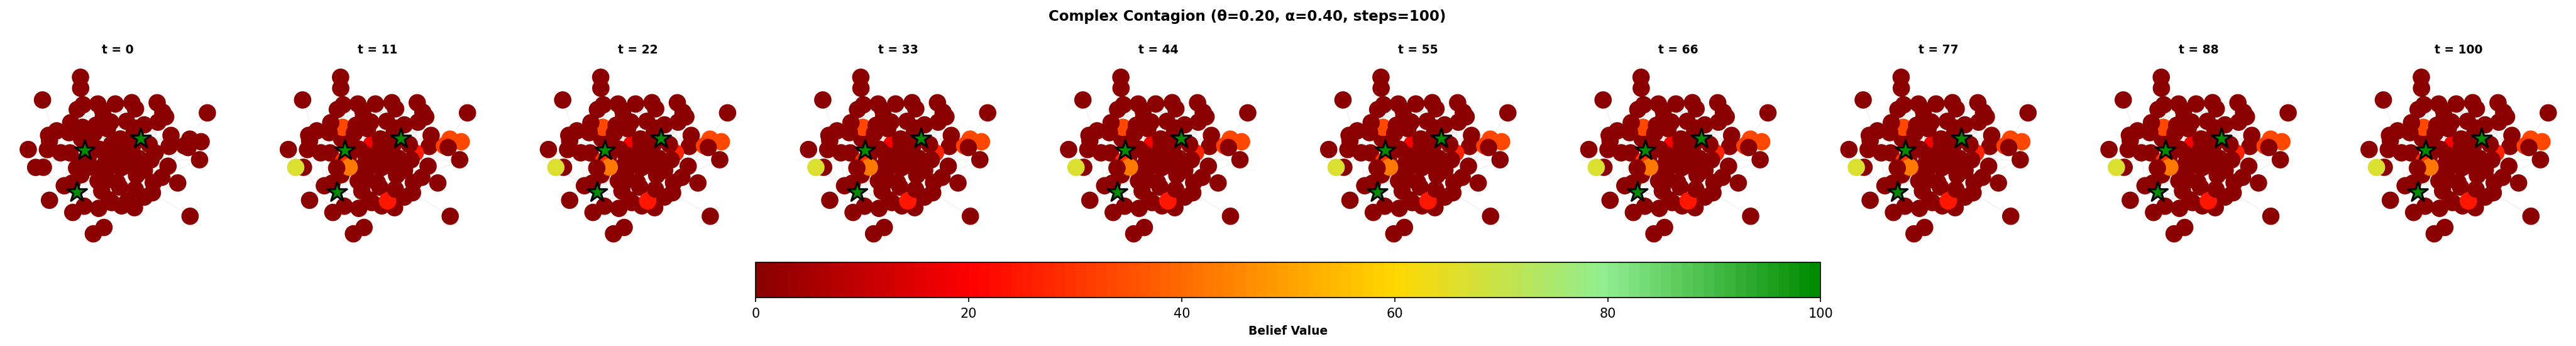

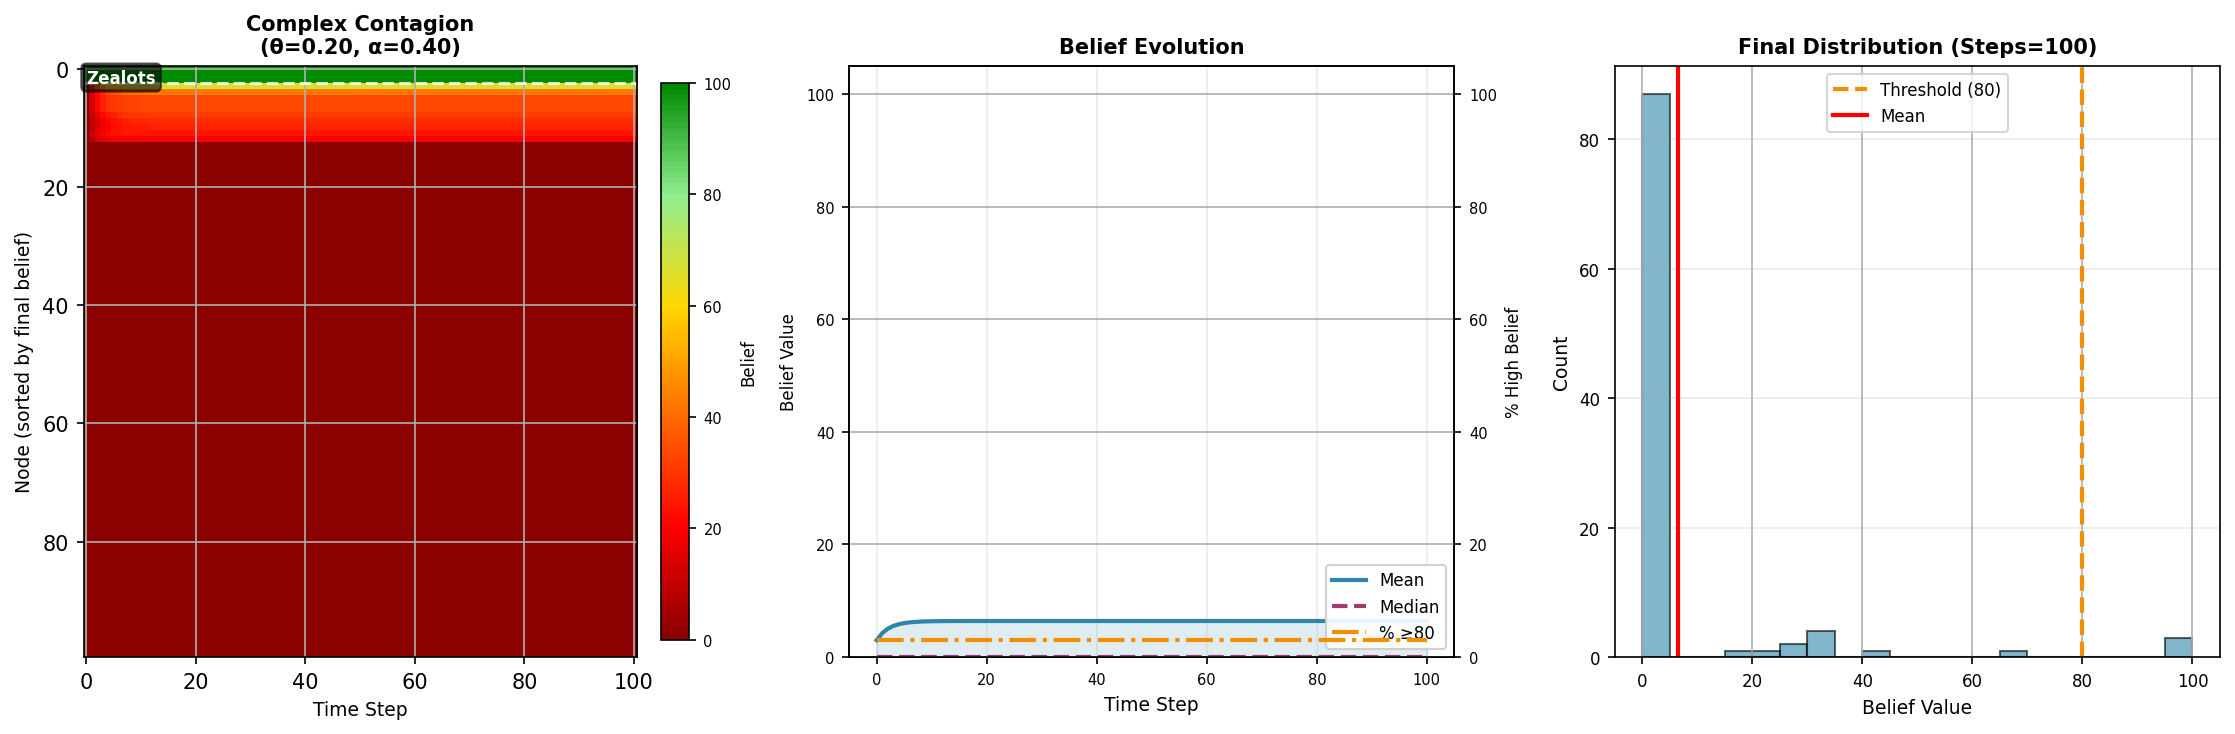

In [83]:
COLOR_PALETTE = {
    'belief_gradient': ['#8B0000', '#FF0000', '#FF6B00', '#FFD700', '#90EE90', '#008B00'],
    'mean_belief': '#2E86AB',
    'median_belief': '#A23B72',
    'high_belief': '#F18F01',
    'threshold_line': '#F18F01',
    'mean_line': 'red',
    'edge': 'gray',
    'zealot_border': 'black'
}

PLOT_CONFIG = {
    'node_size_regular': 150,
    'node_size_zealot': 250,
    'edge_alpha': 0.15,
    'edge_width': 0.5,
    'fill_alpha': 0.15,
    'grid_alpha': 0.25,
    'linewidth': 2.0,
}

# Create colormap once
BELIEF_CMAP = LinearSegmentedColormap.from_list(
    'belief', COLOR_PALETTE['belief_gradient'], N=100
)

def belief_dynamics(
    G: nx.Graph,
    zealots: Sequence,
    steps: int = 15,
    alpha: float = 0.4,
    theta: float = 0.0,
    B_high: float = 80.0,
    rng: Optional[np.random.Generator] = None,
):
    """
    Simulate belief dynamics on a graph.

    - zealots: nodes pinned at belief 100.
    - alpha: learning rate toward neighbor average.
    - theta: complex contagion threshold on fraction of high-belief neighbors.
             theta = 0.0  -> simple contagion-like updating (always update).
    - B_high: threshold for counting a neighbor as high-belief.
    """
    rng = rng or np.random.default_rng()

    nodes = list(G.nodes())
    idx = {u: i for i, u in enumerate(nodes)}
    n = len(nodes)

    beliefs = np.zeros(n)
    zealots_idx = {idx[z] for z in zealots}
    for z in zealots_idx:
        beliefs[z] = 100.0

    history = [beliefs.copy()]

    for t in range(steps):
        new_beliefs = beliefs.copy()
        for u in nodes:
            i = idx[u]
            if i in zealots_idx:
                new_beliefs[i] = 100.0
                continue

            nbrs = list(G.neighbors(u))
            if not nbrs:
                continue

            nbr_vals = beliefs[[idx[v] for v in nbrs]]
            if theta > 0.0:
                frac_high = (nbr_vals >= B_high).mean()
                if frac_high < theta:
                    continue

            nbr_avg = nbr_vals.mean()
            new_beliefs[i] = (1 - alpha) * beliefs[i] + alpha * nbr_avg

        beliefs = new_beliefs
        history.append(beliefs.copy())

    return nodes, np.array(history)

def _get_node_colors(G, nodes, beliefs, zealots):
    """Extract node colors for plotting, separating zealots and regular nodes."""
    zealot_set = set(zealots)
    regular_nodes = [n for n in G.nodes() if n not in zealot_set]
    zealot_nodes = [n for n in G.nodes() if n in zealot_set]
    
    regular_colors = [beliefs[nodes.index(n)] for n in regular_nodes] if regular_nodes else []
    zealot_colors = [beliefs[nodes.index(n)] for n in zealot_nodes] if zealot_nodes else []
    
    return regular_nodes, regular_colors, zealot_nodes, zealot_colors


def _draw_network(ax, G, pos, nodes, beliefs, zealots):
    """Draw network with belief-colored nodes."""
    nx.draw_networkx_edges(G, pos, ax=ax, 
                          alpha=PLOT_CONFIG['edge_alpha'], 
                          width=PLOT_CONFIG['edge_width'],
                          edge_color=COLOR_PALETTE['edge'])
    
    regular_nodes, regular_colors, zealot_nodes, zealot_colors = \
        _get_node_colors(G, nodes, beliefs, zealots)
    
    if regular_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=regular_nodes,
                             node_color=regular_colors,
                             node_size=PLOT_CONFIG['node_size_regular'], 
                             cmap=BELIEF_CMAP, vmin=0, vmax=100, ax=ax)
    
    if zealot_nodes:
        nx.draw_networkx_nodes(G, pos, nodelist=zealot_nodes,
                             node_color=zealot_colors,
                             node_size=PLOT_CONFIG['node_size_zealot'], 
                             cmap=BELIEF_CMAP, vmin=0, vmax=100,
                             node_shape='*', ax=ax, linewidths=1.5, 
                             edgecolors=COLOR_PALETTE['zealot_border'])


def _add_colorbar(fig, ax, label='Belief Value'):
    """Add colorbar to figure."""
    sm = plt.cm.ScalarMappable(cmap=BELIEF_CMAP, norm=plt.Normalize(vmin=0, vmax=100))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', 
                       pad=0.05, aspect=30, shrink=0.8)
    cbar.set_label(label, fontsize=9, fontweight='bold')
    return cbar

def plot_network_snapshots(G, nodes, history, zealots, theta, alpha, 
                          snapshots=None, total_steps=None):
    """
    Plot network at multiple time snapshots with nodes colored by belief,
    plus final distribution histogram.
    
    Args:
        snapshots: list of timesteps to visualize (default: evenly spaced)
        total_steps: total number of steps (for title, default: max in history)
    """
    total_steps = total_steps or (len(history) - 1)
    
    if snapshots is None:
        n_snaps = min(4, total_steps + 1)
        snapshots = np.linspace(0, total_steps, n_snaps, dtype=int).tolist()
    
    n_snaps = len(snapshots)
    fig = plt.figure(figsize=(3.5*n_snaps, 5.5))
    gs = fig.add_gridspec(2, n_snaps, hspace=0.25, height_ratios=[2, 1])
    
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)
    
    # Network snapshots
    axes_net = []
    for ax_idx, t in enumerate(snapshots):
        ax = fig.add_subplot(gs[0, ax_idx])
        axes_net.append(ax)
        t_actual = min(t, len(history)-1)
        beliefs_t = history[t_actual]
        
        _draw_network(ax, G, pos, nodes, beliefs_t, zealots)
        ax.set_title(f't = {t}', fontsize=9, fontweight='bold')
        ax.axis('off')
    
    # Add colorbar
    _add_colorbar(fig, axes_net, label='Belief Value')
    
    contagion_type = "Simple" if theta == 0.0 else "Complex"
    fig.suptitle(f'{contagion_type} Contagion (θ={theta:.2f}, α={alpha:.2f}, steps={total_steps})', 
                fontsize=11, fontweight='bold', y=0.98)
    plt.tight_layout()
    return fig


def plot_belief_heatmap(nodes, history, zealots, theta, alpha, total_steps=None):
    """
    Plot heatmap, time series, and histogram horizontally next to each other 
    with equal ratios.
    
    Args:
        total_steps: total number of steps (for title, default: max in history)
    """
    total_steps = total_steps or (len(history) - 1)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    zealot_set = set(zealots)
    zealot_indices = [i for i, n in enumerate(nodes) if n in zealot_set]
    regular_indices = [i for i, n in enumerate(nodes) if n not in zealot_set]
    
    final_beliefs = history[-1]
    regular_sorted = sorted(regular_indices, 
                           key=lambda i: final_beliefs[i], reverse=True)
    sorted_indices = zealot_indices + regular_sorted
    
    im = ax1.imshow(history[:, sorted_indices].T, aspect='auto', cmap=BELIEF_CMAP,
                   vmin=0, vmax=100, interpolation='nearest')
    
    if zealot_indices:
        ax1.axhline(y=len(zealot_indices)-0.5, color='white', 
                   linewidth=1.5, linestyle='--', alpha=0.8)
        ax1.text(0, len(zealot_indices)/2, 'Zealots', 
                fontsize=8, fontweight='bold', color='white',
                verticalalignment='center', bbox=dict(boxstyle='round', 
                facecolor='black', alpha=0.6, pad=0.3))
    
    ax1.set_xlabel('Time Step', fontsize=9)
    ax1.set_ylabel('Node (sorted by final belief)', fontsize=9)
    contagion_type = "Simple" if theta == 0.0 else "Complex"
    ax1.set_title(f'{contagion_type} Contagion\n(θ={theta:.2f}, α={alpha:.2f})', 
                 fontsize=10, fontweight='bold')
    
    # Add colorbar specifically for the first axis
    cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label('Belief', fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    
    t = np.arange(len(history))
    avg_belief = history.mean(axis=1)
    frac_high = (history >= 80).mean(axis=1)
    median_belief = np.median(history, axis=1)
    
    ax2.plot(t, avg_belief, linewidth=PLOT_CONFIG['linewidth'], 
            label='Mean', color=COLOR_PALETTE['mean_belief'])
    ax2.plot(t, median_belief, linewidth=PLOT_CONFIG['linewidth'], 
            label='Median', color=COLOR_PALETTE['median_belief'], linestyle='--')
    ax2.fill_between(t, 0, avg_belief, alpha=PLOT_CONFIG['fill_alpha'], 
                    color=COLOR_PALETTE['mean_belief'])
    
    ax2_twin = ax2.twinx()
    ax2_twin.plot(t, frac_high * 100, linewidth=PLOT_CONFIG['linewidth'], 
                 label='% ≥80', color=COLOR_PALETTE['high_belief'], linestyle='-.')
    ax2_twin.set_ylabel('% High Belief', fontsize=8)
    ax2_twin.set_ylim([0, 105])
    ax2_twin.tick_params(labelsize=7)
    
    ax2.set_xlabel('Time Step', fontsize=9)
    ax2.set_ylabel('Belief Value', fontsize=8)
    ax2.set_title('Belief Evolution', fontsize=10, fontweight='bold')
    ax2.set_ylim([0, 105])
    ax2.grid(True, alpha=PLOT_CONFIG['grid_alpha'])
    ax2.tick_params(labelsize=7)
    
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, 
              loc='lower right', fontsize=8, framealpha=0.9)
    
    beliefs_final = history[-1]
    ax3.hist(beliefs_final, bins=20, color=COLOR_PALETTE['mean_belief'], 
            alpha=0.6, edgecolor='black', linewidth=1)
    ax3.axvline(80, color=COLOR_PALETTE['threshold_line'], 
               linestyle='--', linewidth=2, label='Threshold (80)')
    ax3.axvline(beliefs_final.mean(), color=COLOR_PALETTE['mean_line'], 
               linestyle='-', linewidth=2, label='Mean')
    
    ax3.set_xlabel('Belief Value', fontsize=9)
    ax3.set_ylabel('Count', fontsize=9)
    ax3.set_title(f'Final Distribution (Steps={total_steps})', fontsize=10, fontweight='bold')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=PLOT_CONFIG['grid_alpha'], axis='y')
    ax3.tick_params(labelsize=8)
    
    plt.tight_layout()
    return fig


rng = np.random.default_rng(42)

# example G: ER network. You can change it to WS or BA as needed.
G_example = nx.erdos_renyi_graph(100, 0.05, seed=42)
# G_example = nx.watts_strogatz_graph(100, 6, 0.1, seed=42)
# G_example = nx.barabasi_albert_graph(100, 3, seed=42)

zealots_example = rng.choice(list(G_example.nodes()), size=3, replace=False).tolist()
total_steps = 100
snapshot = np.linspace(0, total_steps, 10, dtype=int).tolist()

# Simple contagion
nodes_simple, history_simple = belief_dynamics(
    G_example, zealots_example, steps=total_steps, alpha=0.4, theta=0.0, rng=rng
)
fig_simple = plot_network_snapshots(
    G_example, nodes_simple, history_simple, zealots_example, 
    theta=0.0, alpha=0.4, snapshots=snapshot
)
fig_simple_heatmap = plot_belief_heatmap(
    nodes_simple, history_simple, zealots_example, 
    theta=0.0, alpha=0.4, total_steps=total_steps
)

# Complex contagion
nodes_complex, history_complex = belief_dynamics(
    G_example, zealots_example, steps=total_steps, alpha=0.4, theta=0.2, rng=rng
)
fig_complex = plot_network_snapshots(
    G_example, nodes_complex, history_complex, zealots_example, 
    theta=0.2, alpha=0.4, snapshots=snapshot
)
fig_complex_heatmap = plot_belief_heatmap(
    nodes_complex, history_complex, zealots_example, 
    theta=0.2, alpha=0.4, total_steps=total_steps
)

plt.show()

### Your Turn

Implement a contagion model of your choice, experiment with parameters, and visualize the results. We studied how changes in probability \(p\) (for IC) or threshold distributions (for WTM) affect the spread dynamics on different network structures. Now, try changing the graph density (keep the \(p\) and threshold distributions constant, also control for average degree) and see how that shapes contagion.

## How Structure Shapes Cascades

We examine how **degree heterogeneity** (ER vs BA) and **clustering/shortcuts** (WS with rewiring \(\beta\)) alter cascade sizes under IC and WTM.

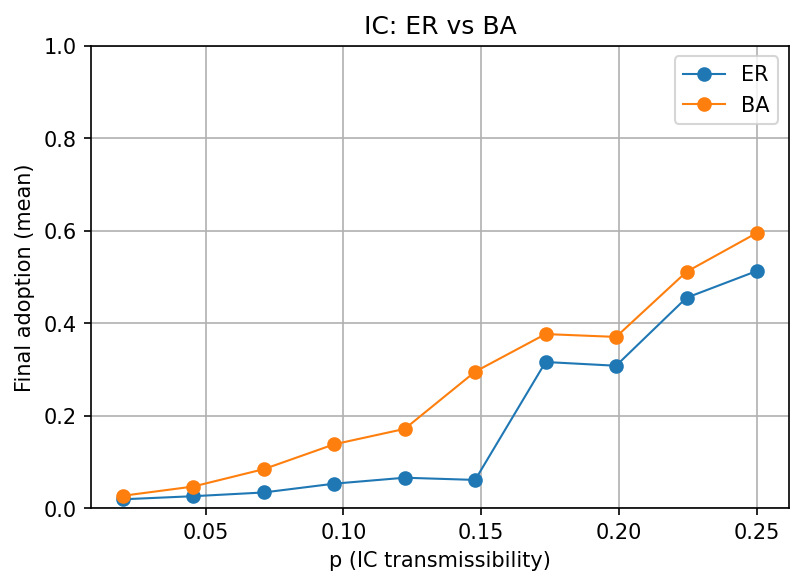

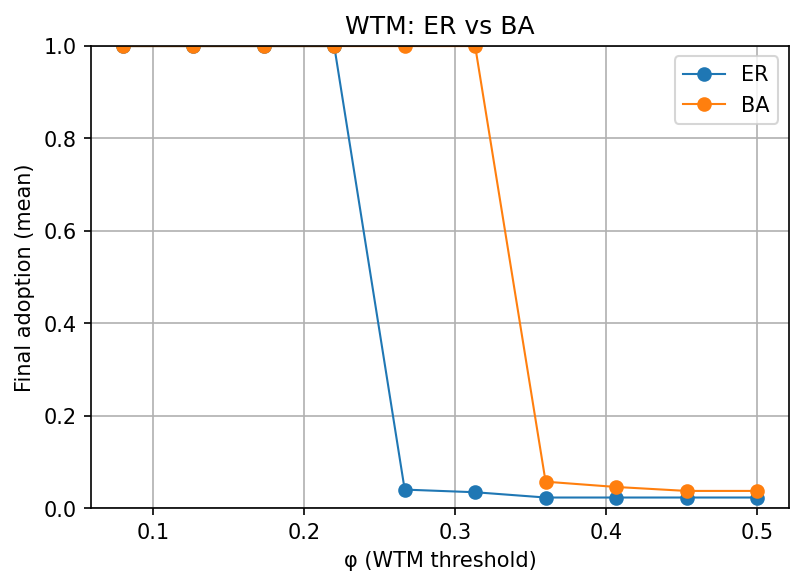

In [84]:

def make_graph(kind: str = "ER", n: int = 400, avg_k: float = 6, beta: float = 0.1, rng=None) -> nx.Graph:
    rng = rng or np.random.default_rng()
    if kind.upper() == "ER":
        p = avg_k/(n-1); return nx.erdos_renyi_graph(n, p, seed=rng)
    if kind.upper() == "WS":
        k = int(round(avg_k)); k += (k%2); return nx.watts_strogatz_graph(n, k, beta, seed=rng)
    if kind.upper() == "BA":
        m = max(1, int(round(avg_k/2))); return nx.barabasi_albert_graph(n, m, seed=rng)
    raise ValueError

def sweep_ic(G, seeds, ps, runs=10, rng=None):
    rng = rng or np.random.default_rng()
    rows = []
    for p in ps:
        for r in range(runs):
            res = simulate_ic(G, seeds, p=p, rng=rng)
            rows.append(dict(p=p, frac=len(res.adopted)/G.number_of_nodes()))
    return pd.DataFrame(rows)

def sweep_wtm(G, seeds, phis, runs=1, rng=None):
    rng = rng or np.random.default_rng()
    rows = []
    for phi in phis:
        for r in range(runs):
            res = simulate_wtm(G, seeds, phi=phi, rng=rng)
            rows.append(dict(phi=phi, frac=len(res.adopted)/G.number_of_nodes()))
    return pd.DataFrame(rows)

G_er = make_graph("ER", n=350, avg_k=6, rng=rng)
G_ba = make_graph("BA", n=350, avg_k=6, rng=rng)
seeds_er = choose_seeds(G_er, 5, method="degree", rng=rng)
seeds_ba = choose_seeds(G_ba, 5, method="degree", rng=rng)

ps   = np.linspace(0.02, 0.25, 10)
phis = np.linspace(0.08, 0.5, 10)

df_er_ic = sweep_ic(G_er, seeds_er, ps, runs=6, rng=rng)
df_ba_ic = sweep_ic(G_ba, seeds_ba, ps, runs=6, rng=rng)
df_er_wt = sweep_wtm(G_er, seeds_er, phis, runs=1, rng=rng)
df_ba_wt = sweep_wtm(G_ba, seeds_ba, phis, runs=1, rng=rng)

plt.plot(df_er_ic.groupby("p")["frac"].mean(), marker="o", lw=1, label="ER")
plt.plot(df_ba_ic.groupby("p")["frac"].mean(), marker="o", lw=1, label="BA")
plt.xlabel("p (IC transmissibility)"); plt.ylabel("Final adoption (mean)")
plt.ylim(0,1); plt.title("IC: ER vs BA"); plt.legend(); plt.show()

plt.plot(df_er_wt.groupby("phi")["frac"].mean(), marker="o", lw=1, label="ER")
plt.plot(df_ba_wt.groupby("phi")["frac"].mean(), marker="o", lw=1, label="BA")
plt.xlabel("φ (WTM threshold)"); plt.ylabel("Final adoption (mean)")
plt.ylim(0,1); plt.title("WTM: ER vs BA"); plt.legend(); plt.show()


In [85]:
# get subgraph of largest connected component
def largest_cc_subgraph(G: nx.Graph) -> nx.Graph:
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()
    
def ws_graph(n=300, k=6, beta=0.05, seed=None):
    k = k + (k % 2)
    return nx.watts_strogatz_graph(n, k, beta, seed=seed)

def summarize_graph(G: nx.Graph):
    return nx.average_shortest_path_length(G), nx.average_clustering(G)

def path_length_hist(G: nx.Graph, bins=None, samples=4000, rng=None):
    rng = rng or np.random.default_rng()
    nodes = list(G.nodes())
    m = min(samples, len(nodes)*(len(nodes)-1)//2)
    pairs = [(rng.integers(0, len(nodes)), rng.integers(0, len(nodes))) for _ in range(m)]
    dists = []
    for i,j in pairs:
        if i == j: 
            continue
        try:
            dists.append(nx.shortest_path_length(G, nodes[i], nodes[j]))
        except nx.NetworkXNoPath:
            pass
    if not dists:
        return
    if bins is None:
        bins = np.arange(0, max(dists)+2)
    plt.hist(dists, bins=bins, density=True)
    plt.xlabel("Shortest-path length")
    plt.ylabel("Density")
    plt.title("Geodesic length distribution")
    plt.show()

Gs = {
    "Lattice-like (β=0)":   ws_graph(n=1000, k=6, beta=0.0, seed=rng),
    "Small-world (β=0.1)": ws_graph(n=1000, k=6, beta=0.1, seed=rng),
    "Random-like (β=1)":    ws_graph(n=1000, k=6, beta=1.0, seed=rng),
    # connected random graph with same n, m; make sure it's connected
    "Erdős-Rényi (p=0.024)": largest_cc_subgraph(nx.erdos_renyi_graph(n=1000, p=6/999, seed=rng, directed=False))
}

rows = []
for name, G in Gs.items():
    L, C = summarize_graph(G)
    rows.append(dict(model=name, L=L, C=C))
pd.DataFrame(rows)


,model,L,C
0,Lattice-like (β=0),83.750751,0.600000
1,Small-world (β=0.1),6.131762,0.448844
2,Random-like (β=1),4.104100,0.006283
3,Erdős-Rényi (p=0.024),4.044499,0.007271


Small-world (β=0.1):


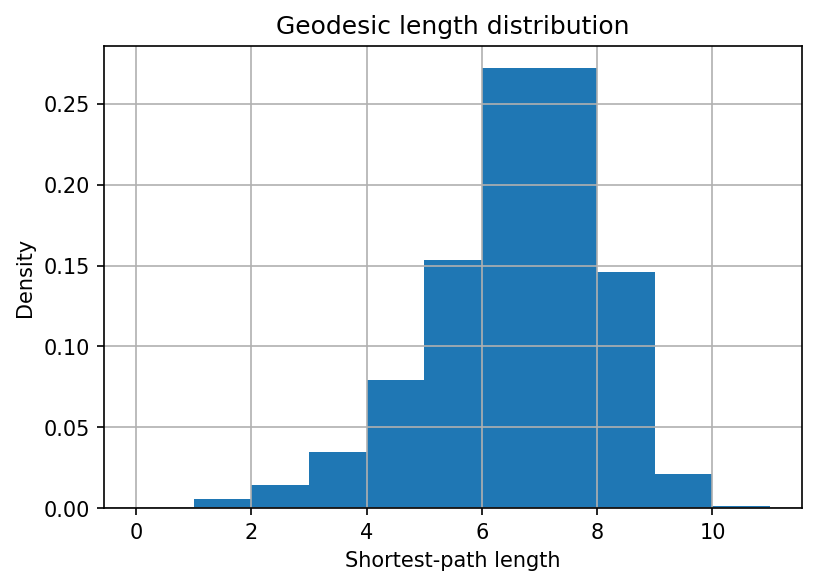

Lattice-like (β=0):


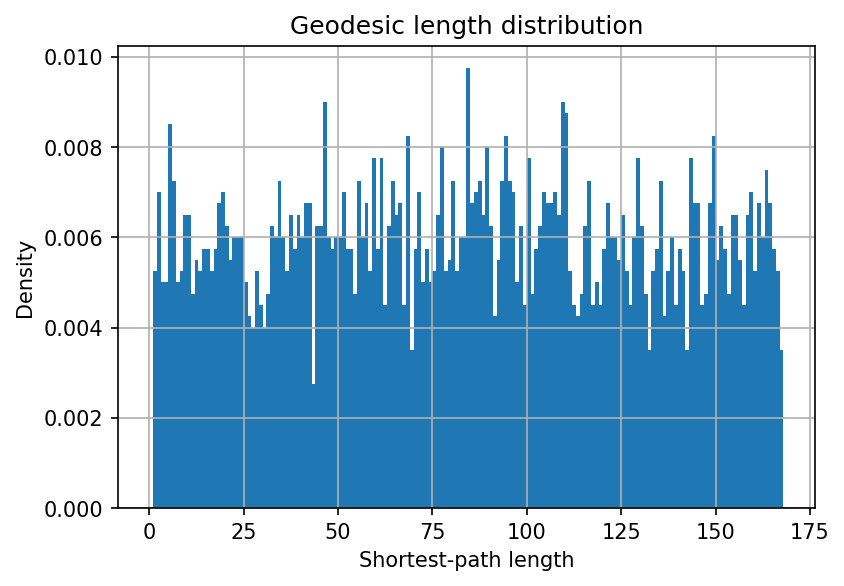

Random-like (β=1):


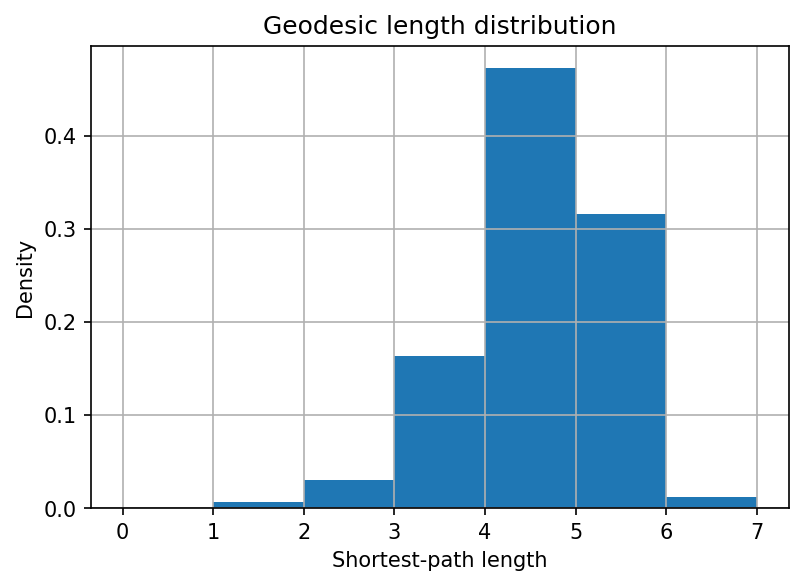

Erdős-Rényi (p=0.024):


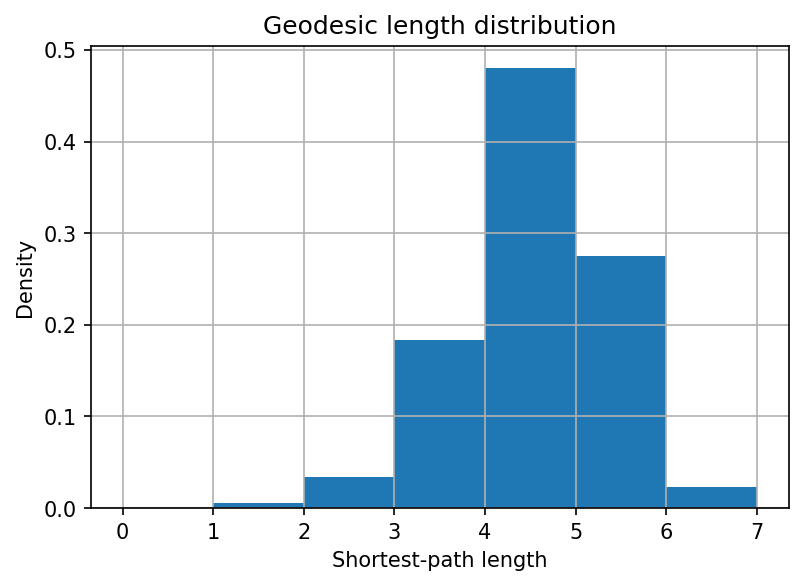

In [86]:
# Path-length distributions in the small-world regime
print("Small-world (β=0.1):")
path_length_hist(Gs["Small-world (β=0.1)"], rng=rng)
print("Lattice-like (β=0):")
path_length_hist(Gs["Lattice-like (β=0)"], rng=rng)
print("Random-like (β=1):")
path_length_hist(Gs["Random-like (β=1)"], rng=rng)
print("Erdős-Rényi (p=0.024):")
path_length_hist(Gs["Erdős-Rényi (p=0.024)"], rng=rng)

### Your Turn

**Your turn:**

Plot the following for both IC and WRM: 
1. **Degree heterogeneity** (ER vs BA).
2. **Clustering / small-world** (WS with varying rewiring \( \beta \)).
3. **Community structure** (e.g., planted partition; optional extension).

### Your Turn

**Your turn:**
- For fixed $n, \langle k \rangle$, compare IC vs WTM final adoption on ER vs BA across parameter sweeps.
- For WS, vary $\beta \in [0,1]$ and show: IC global adoption typically rises with $\beta$; WTM often shows a peak at *intermediate* $\beta$ due to a balance of reinforcement and reach.

### A Question for practice

This question explores the spread of a simple contagion on different types of networks using random walks to simulate the contagion process. The goal is to analyze how the structure of the network affects the spread of the contagion over time.

Implement a function to simulate the spread of a simple contagion on a given network using random walks. The function should take as input a network (as a NetworkX graph), a set of initially infected nodes, and the number of time steps to simulate. At each time step, each infected node should randomly infect one of its neighbors, and remain infected for the duration of the simulation. The function should return the fraction of infected nodes at each time step. It is expected that all nodes will eventually become infected.

Fraction of infected nodes over time: [0.004 0.008 0.016 0.028 0.05  0.09  0.162 0.274 0.45  0.628 0.756 0.886
 0.94  0.97  0.986 0.994 0.994 0.994 1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    1.    1.   ]


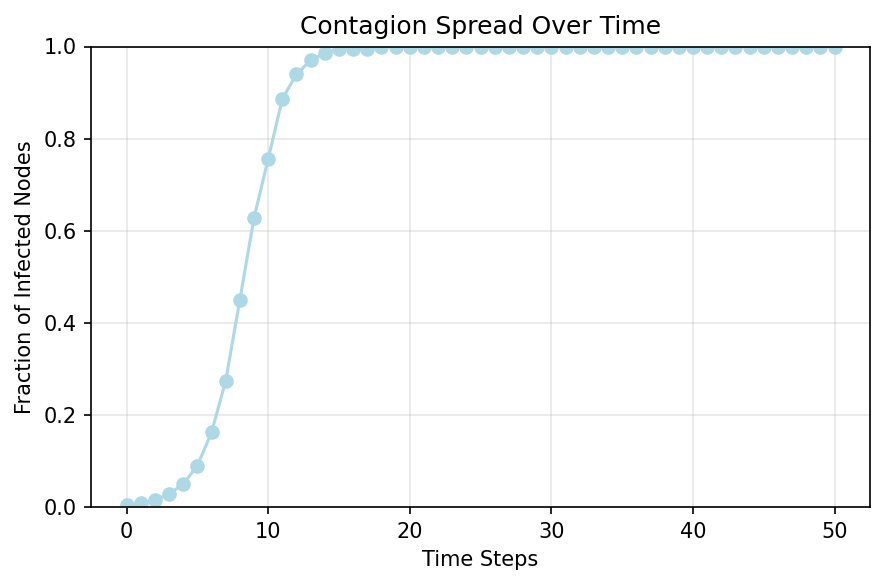

In [93]:
def simulate_contagion_spread(G, initial_infected, steps):
    """
    Simulate contagion spreading on graph G starting from initial_infected nodes
    for a given number of steps.

    Returns:
        fractions: np.array of length (steps+1),
                   fraction of infected nodes at each time step.
    """
    n_nodes = G.number_of_nodes()
    infected = set(initial_infected)
    newly_infected = set(initial_infected)

    # Record initial state (t = 0)
    fractions = [len(infected) / n_nodes]

    for step in range(steps):
        next_newly_infected = set()
        for node in infected:  # <--- all infected, not just newly infected
            neighbors = list(G.neighbors(node))
            if neighbors:
                chosen_neighbor = np.random.choice(neighbors)
                if chosen_neighbor not in infected:
                    next_newly_infected.add(chosen_neighbor)
        infected.update(next_newly_infected)

        fractions.append(len(infected) / n_nodes)
        
        if len(infected) == n_nodes:
            # Pad with final value up to steps+1 length
            fractions.extend([1.0] * (steps - step))
            break

    return np.array(fractions[:steps+1])

G = nx.erdos_renyi_graph(500, 0.05)
initial_infected = [0, 1]
steps = 50
fractions = simulate_contagion_spread(G, initial_infected, steps)
print("Fraction of infected nodes over time:", fractions)

plt.figure(figsize=(6, 4))
plt.plot(range(steps + 1), fractions, marker='o', color='lightblue')
plt.title('Contagion Spread Over Time', fontsize=12)
plt.xlabel('Time Steps', fontsize=10)
plt.ylabel('Fraction of Infected Nodes', fontsize=10)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now, implement various network types (Erdős-Rényi, Barabási-Albert, Watts-Strogatz) using NetworkX. For each network type, generate networks of varying sizes (e.g., 100, 500, 1000 nodes) and simulate the contagion spread using the function from part (a). Plot the fraction of infected nodes over time for each network type and size. Analyze and compare the results to understand how network structure influences contagion dynamics.

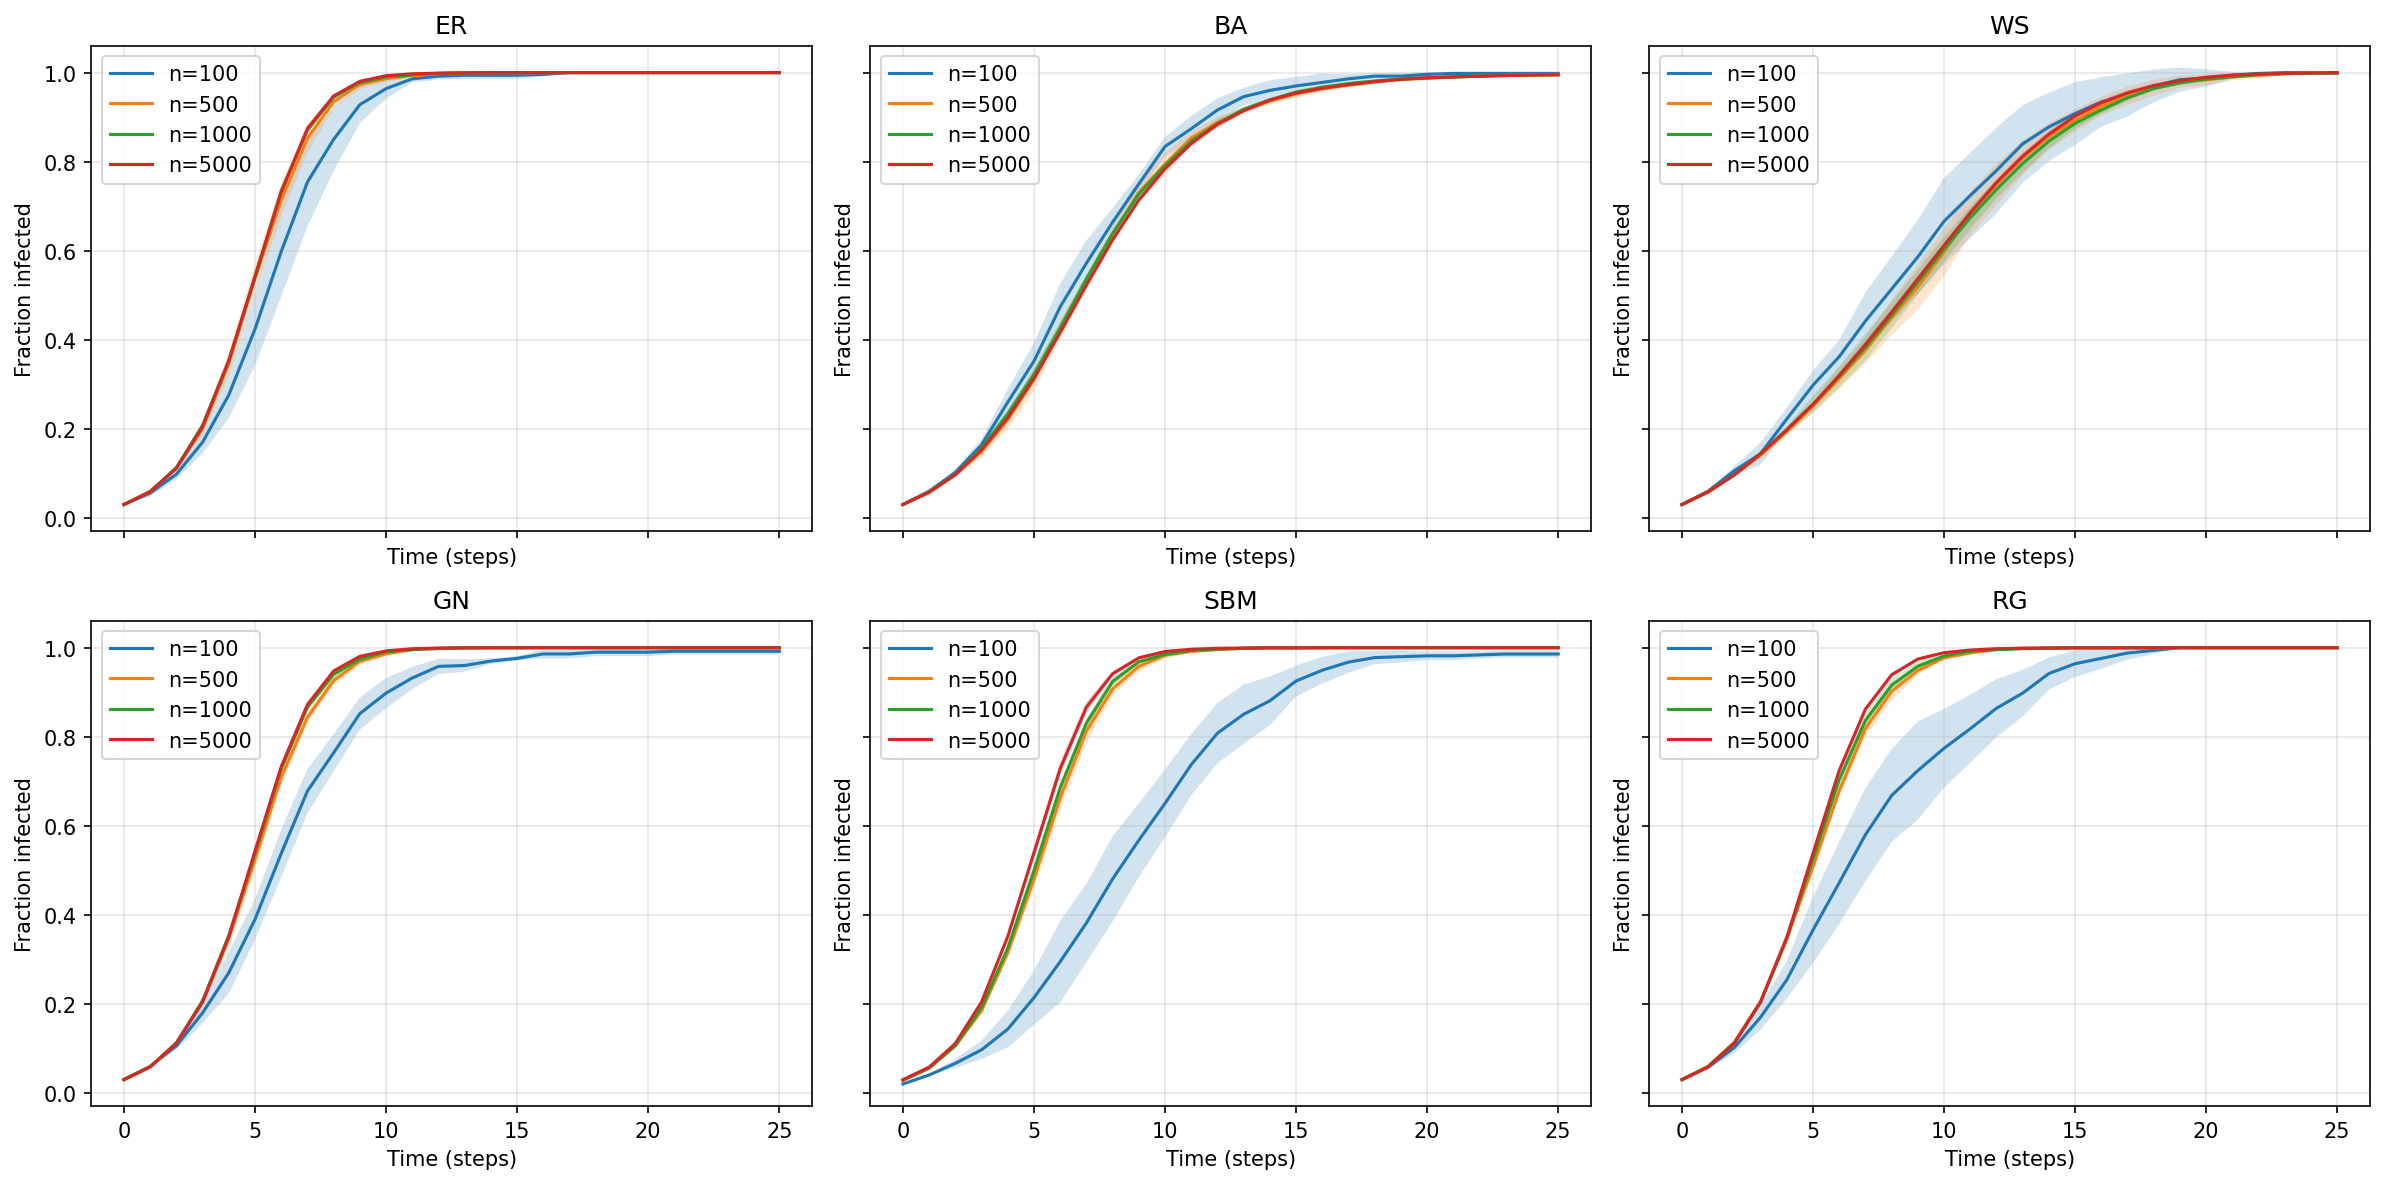

In [94]:
# Network tyoes
network_types = {
    'ER': nx.erdos_renyi_graph,
    'BA': nx.barabasi_albert_graph,
    'WS': nx.watts_strogatz_graph,
    'GN': nx.random_partition_graph,
    'SBM': nx.stochastic_block_model,
    'RG': nx.random_geometric_graph,
}

sizes = [100, 500, 1000, 5000]
steps = 25
n_runs = 5

# results[ntype][size] -> array of shape (n_runs, steps+1)
results = {
    ntype: {size: [] for size in sizes}
    for ntype in network_types.keys()
}

# initial infected nodes: 0.05 of nodes
initial_infected_fraction = 0.03

for ntype, gen_func in network_types.items():
    for size in sizes:
        for run in range(n_runs):
            # Generate graph according to type
            if ntype == 'ER':
                G = gen_func(size, 0.1)

            elif ntype == 'BA':
                # m must be < size, 3 is fine for the given sizes
                G = gen_func(size, 3)

            elif ntype == 'WS':
                # k must be even and <= size; 4 is fine here
                G = gen_func(size, 4, 0.1)

            elif ntype == 'GN':
                # Two equal partitions (works fine for even sizes)
                sizes_partition = [size // 2, size // 2]
                p_intra = 0.1
                p_inter = 0.01
                G = gen_func(sizes_partition, p_intra, p_inter)

            elif ntype == 'SBM':
                # Three partitions; make sure total nodes comes from the graph itself
                base = size // 3
                sizes_partition = [base, base, base]
                p_matrix = [[0.1, 0.01, 0.01],
                            [0.01, 0.1, 0.01],
                            [0.01, 0.01, 0.1]]
                G = gen_func(sizes_partition, p_matrix)

            elif ntype == 'RG':
                G = gen_func(size, radius=0.2)
            else:
                raise ValueError(f"Unknown network type: {ntype}")

            # Pick initial infected nodes
            n_nodes = G.number_of_nodes()
            # Ensure we don't ask for more initial infected than nodes
            n_initial = max(1, int(initial_infected_fraction * n_nodes))
            initial_infected = np.random.choice(list(G.nodes()), size=n_initial, replace=False)

            fractions = simulate_contagion_spread(G, initial_infected, steps)
            results[ntype][size].append(fractions)

        # Convert list of runs to array: shape (n_runs, steps+1)
        results[ntype][size] = np.vstack(results[ntype][size])

time = np.arange(steps + 1)
n_types = len(network_types)
n_rows = 2
n_cols = int(np.ceil(n_types / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (ntype, size_dict) in zip(axes, results.items()):
    for size, runs_array in size_dict.items():
        # runs_array shape: (n_runs, steps+1)
        mean_frac = runs_array.mean(axis=0)
        var_frac = runs_array.var(axis=0)
        std_frac = np.sqrt(var_frac)

        # Plot mean
        ax.plot(time, mean_frac, label=f"n={size}")

        # Shaded variance band: mean ± std
        ax.fill_between(time,
                        mean_frac - std_frac,
                        mean_frac + std_frac,
                        alpha=0.2)

    ax.set_title(ntype)
    ax.set_xlabel("Time (steps)")
    ax.set_ylabel("Fraction infected")
    ax.grid(True, alpha=0.3)
    ax.legend()

# If there are unused subplots, hide them
for i in range(len(results), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


Now, modify the simulation function so that each infected node becomes inactive after infecting a neighbor.
So each node can create at most one child in the infection tree. After that, it’s “done” and never spreads again.

Fraction of infected nodes over time: [0.004 0.008 0.012 0.016 0.02  0.024 0.028 0.032 0.034 0.036 0.038 0.04
 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042
 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042
 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042 0.042
 0.042 0.042 0.042]


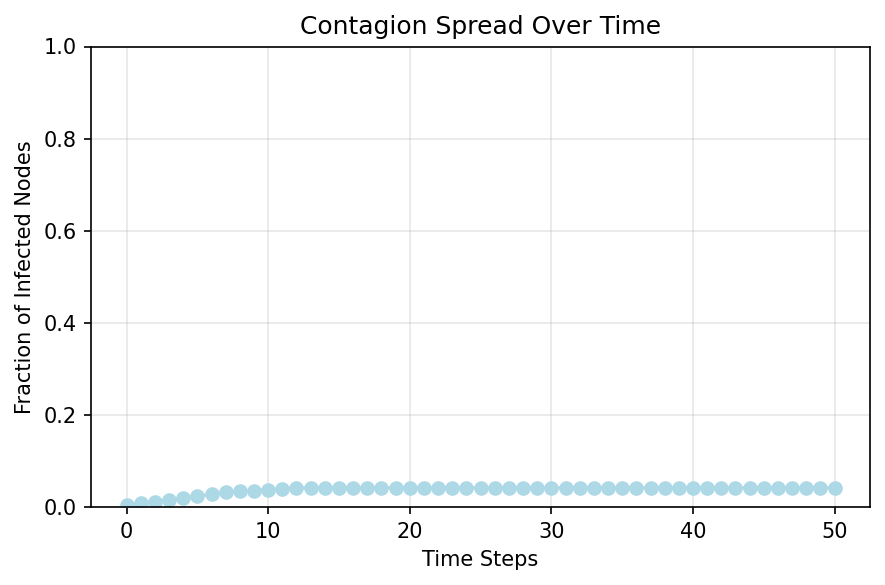

In [95]:
def simulate_contagion_spread_inactive(G, initial_infected, steps):
    """
    Simulate contagion spreading on graph G starting from initial_infected nodes
    for a given number of steps.

    Returns:
        fractions: np.array of length (steps+1),
                   fraction of infected nodes at each time step.
    """
    n_nodes = G.number_of_nodes()
    infected = set(initial_infected)
    newly_infected = set(initial_infected)

    # Record initial state (t = 0)
    fractions = [len(infected) / n_nodes]

    for step in range(steps):
        next_newly_infected = set()
        for node in newly_infected:
            neighbors = list(G.neighbors(node))
            if neighbors:
                chosen_neighbor = np.random.choice(neighbors)
                if chosen_neighbor not in infected:
                    next_newly_infected.add(chosen_neighbor)
        infected.update(next_newly_infected)
        newly_infected = next_newly_infected

        fractions.append(len(infected) / n_nodes)

        # Optional early stopping if fully infected
        if len(infected) == n_nodes:
            print(f"All nodes infected by step {step+1}. Stopping early.")
            # Pad with final value up to steps+1 length
            fractions.extend([1.0] * (steps - step))
            break

    return np.array(fractions[:steps+1])

G = nx.erdos_renyi_graph(500, 0.05)
initial_infected = [0, 1]
steps = 50
fractions = simulate_contagion_spread_inactive(G, initial_infected, steps)
print("Fraction of infected nodes over time:", fractions)

plt.figure(figsize=(6, 4))
plt.plot(range(steps + 1), fractions, marker='o', color='lightblue')
plt.title('Contagion Spread Over Time', fontsize=12)
plt.xlabel('Time Steps', fontsize=10)
plt.ylabel('Fraction of Infected Nodes', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

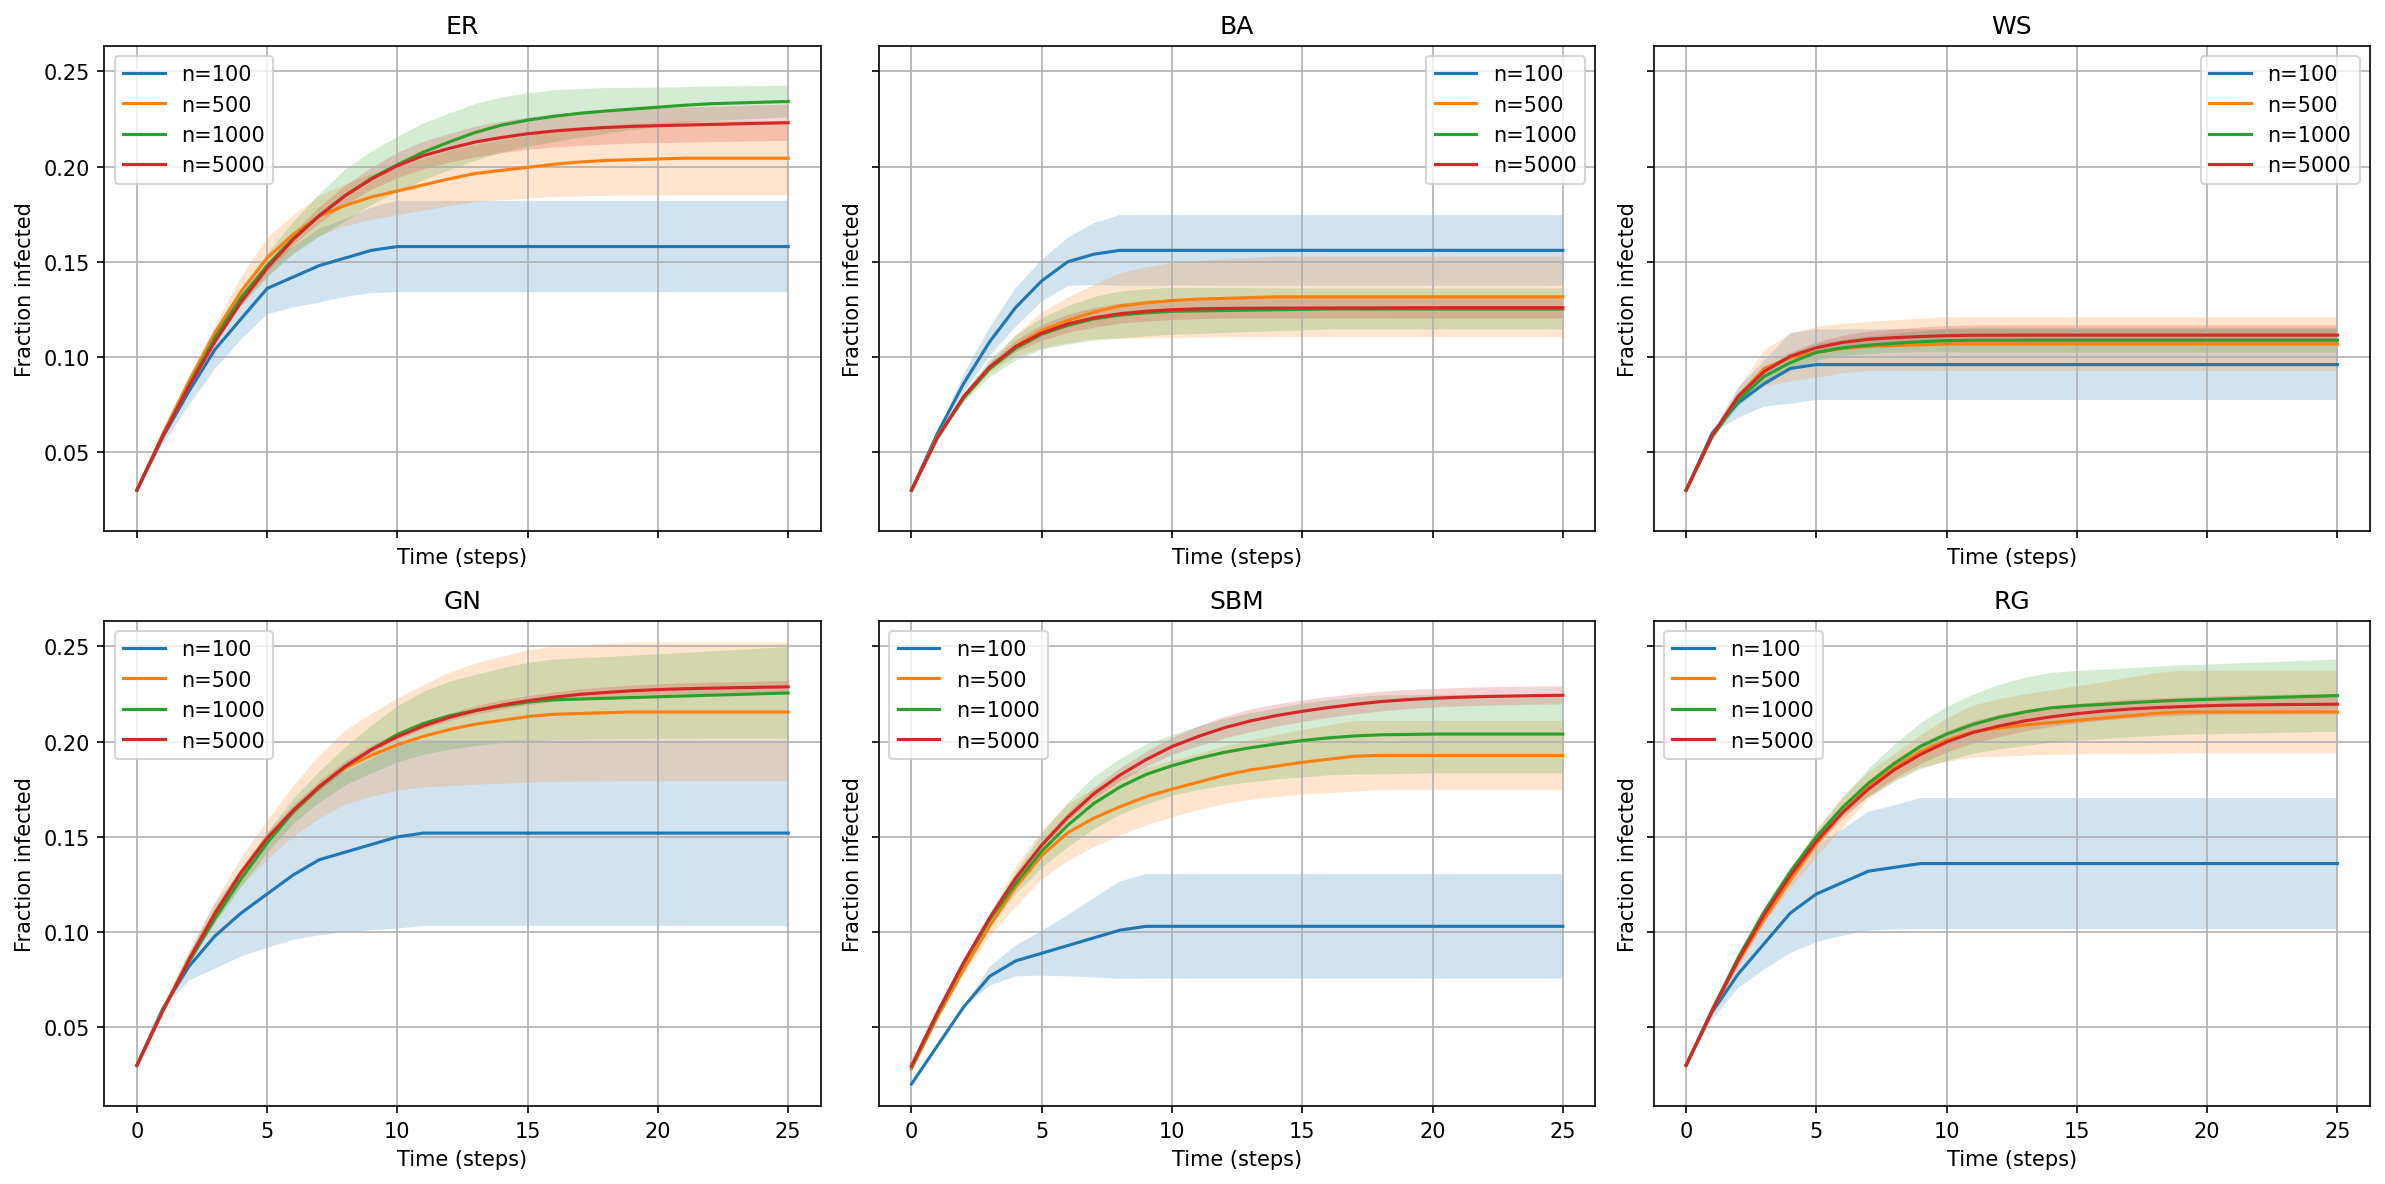

In [16]:
network_types = {
    'ER': nx.erdos_renyi_graph,
    'BA': nx.barabasi_albert_graph,
    'WS': nx.watts_strogatz_graph,
    'GN': nx.random_partition_graph,
    'SBM': nx.stochastic_block_model,
    'RG': nx.random_geometric_graph,
}

sizes = [100, 500, 1000, 5000]
steps = 25
n_runs = 5

# results[ntype][size] -> array of shape (n_runs, steps+1)
results = {
    ntype: {size: [] for size in sizes}
    for ntype in network_types.keys()
}

# all_graphs[ntype][size]['sample_i'] -> stored NetworkX graph
all_graphs = {
    ntype: {size: {} for size in sizes}
    for ntype in network_types.keys()
}

# initial infected nodes: 3% of nodes
initial_infected_fraction = 0.03

for ntype, gen_func in network_types.items():
    for size in sizes:
        for run in range(n_runs):
            # Generate graph according to type
            if ntype == 'ER':
                G = gen_func(size, 0.1)

            elif ntype == 'BA':
                G = gen_func(size, 3)

            elif ntype == 'WS':
                G = gen_func(size, 4, 0.1)

            elif ntype == 'GN':
                sizes_partition = [size // 2, size // 2]
                p_intra = 0.1
                p_inter = 0.01
                G = gen_func(sizes_partition, p_intra, p_inter)

            elif ntype == 'SBM':
                base = size // 3
                sizes_partition = [base, base, base]
                p_matrix = [[0.1, 0.01, 0.01],
                            [0.01, 0.1, 0.01],
                            [0.01, 0.01, 0.1]]
                G = gen_func(sizes_partition, p_matrix)

            elif ntype == 'RG':
                G = gen_func(size, radius=0.2)
            else:
                raise ValueError(f"Unknown network type: {ntype}")

            # ---- store graph for later use ----
            sample_key = f"sample_{run+1}"
            all_graphs[ntype][size][sample_key] = G

            # Pick initial infected nodes
            n_nodes = G.number_of_nodes()
            n_initial = max(1, int(initial_infected_fraction * n_nodes))
            initial_infected = np.random.choice(list(G.nodes()), size=n_initial, replace=False)

            fractions = simulate_contagion_spread_inactive(G, initial_infected, steps)
            results[ntype][size].append(fractions)

        # Convert list of runs to array: shape (n_runs, steps+1)
        results[ntype][size] = np.vstack(results[ntype][size])

# ---- plotting as before ----
time = np.arange(steps + 1)
n_types = len(network_types)
n_rows = 2
n_cols = int(np.ceil(n_types / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (ntype, size_dict) in zip(axes, results.items()):
    for size, runs_array in size_dict.items():
        mean_frac = runs_array.mean(axis=0)
        std_frac = runs_array.std(axis=0)

        ax.plot(time, mean_frac, label=f"n={size}")
        ax.fill_between(time, mean_frac - std_frac, mean_frac + std_frac, alpha=0.2)

    ax.set_title(ntype)
    ax.set_xlabel("Time (steps)")
    ax.set_ylabel("Fraction infected")
    ax.grid(True)
    ax.legend()

for i in range(len(results), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


Now, study the spectral properties of the networks used in part (c). For each network type and size, let P = D^(-1) A be the random-walk matrix of the network, where A is the adjacency matrix and D is the diagonal degree matrix. Compute the eigenvalues of P for each network type and size, and plot the spectral density. Analyze how the spectral properties relate to the contagion dynamics observed in part (c). Discuss any correlations between the spectral characteristics of the networks and the speed or extent of contagion spread.

Hint: you can get A and D from NetworkX package.

Then, numerically compute the largest few eigenvalues of P for each network type and size. Then, estimate the spectral gap (gamma = lambda_1 - lambda_2) for each graph.

First, we will compute the eigenvalues of the random-walk matrix P. If the graph is larger than 5000 nodesm, we will pick 500 largest eigenvalues using sparse methods; otherwise, we will compute all eigenvalues using dense methods. Then, we will plot the spectral density for each network type and size.

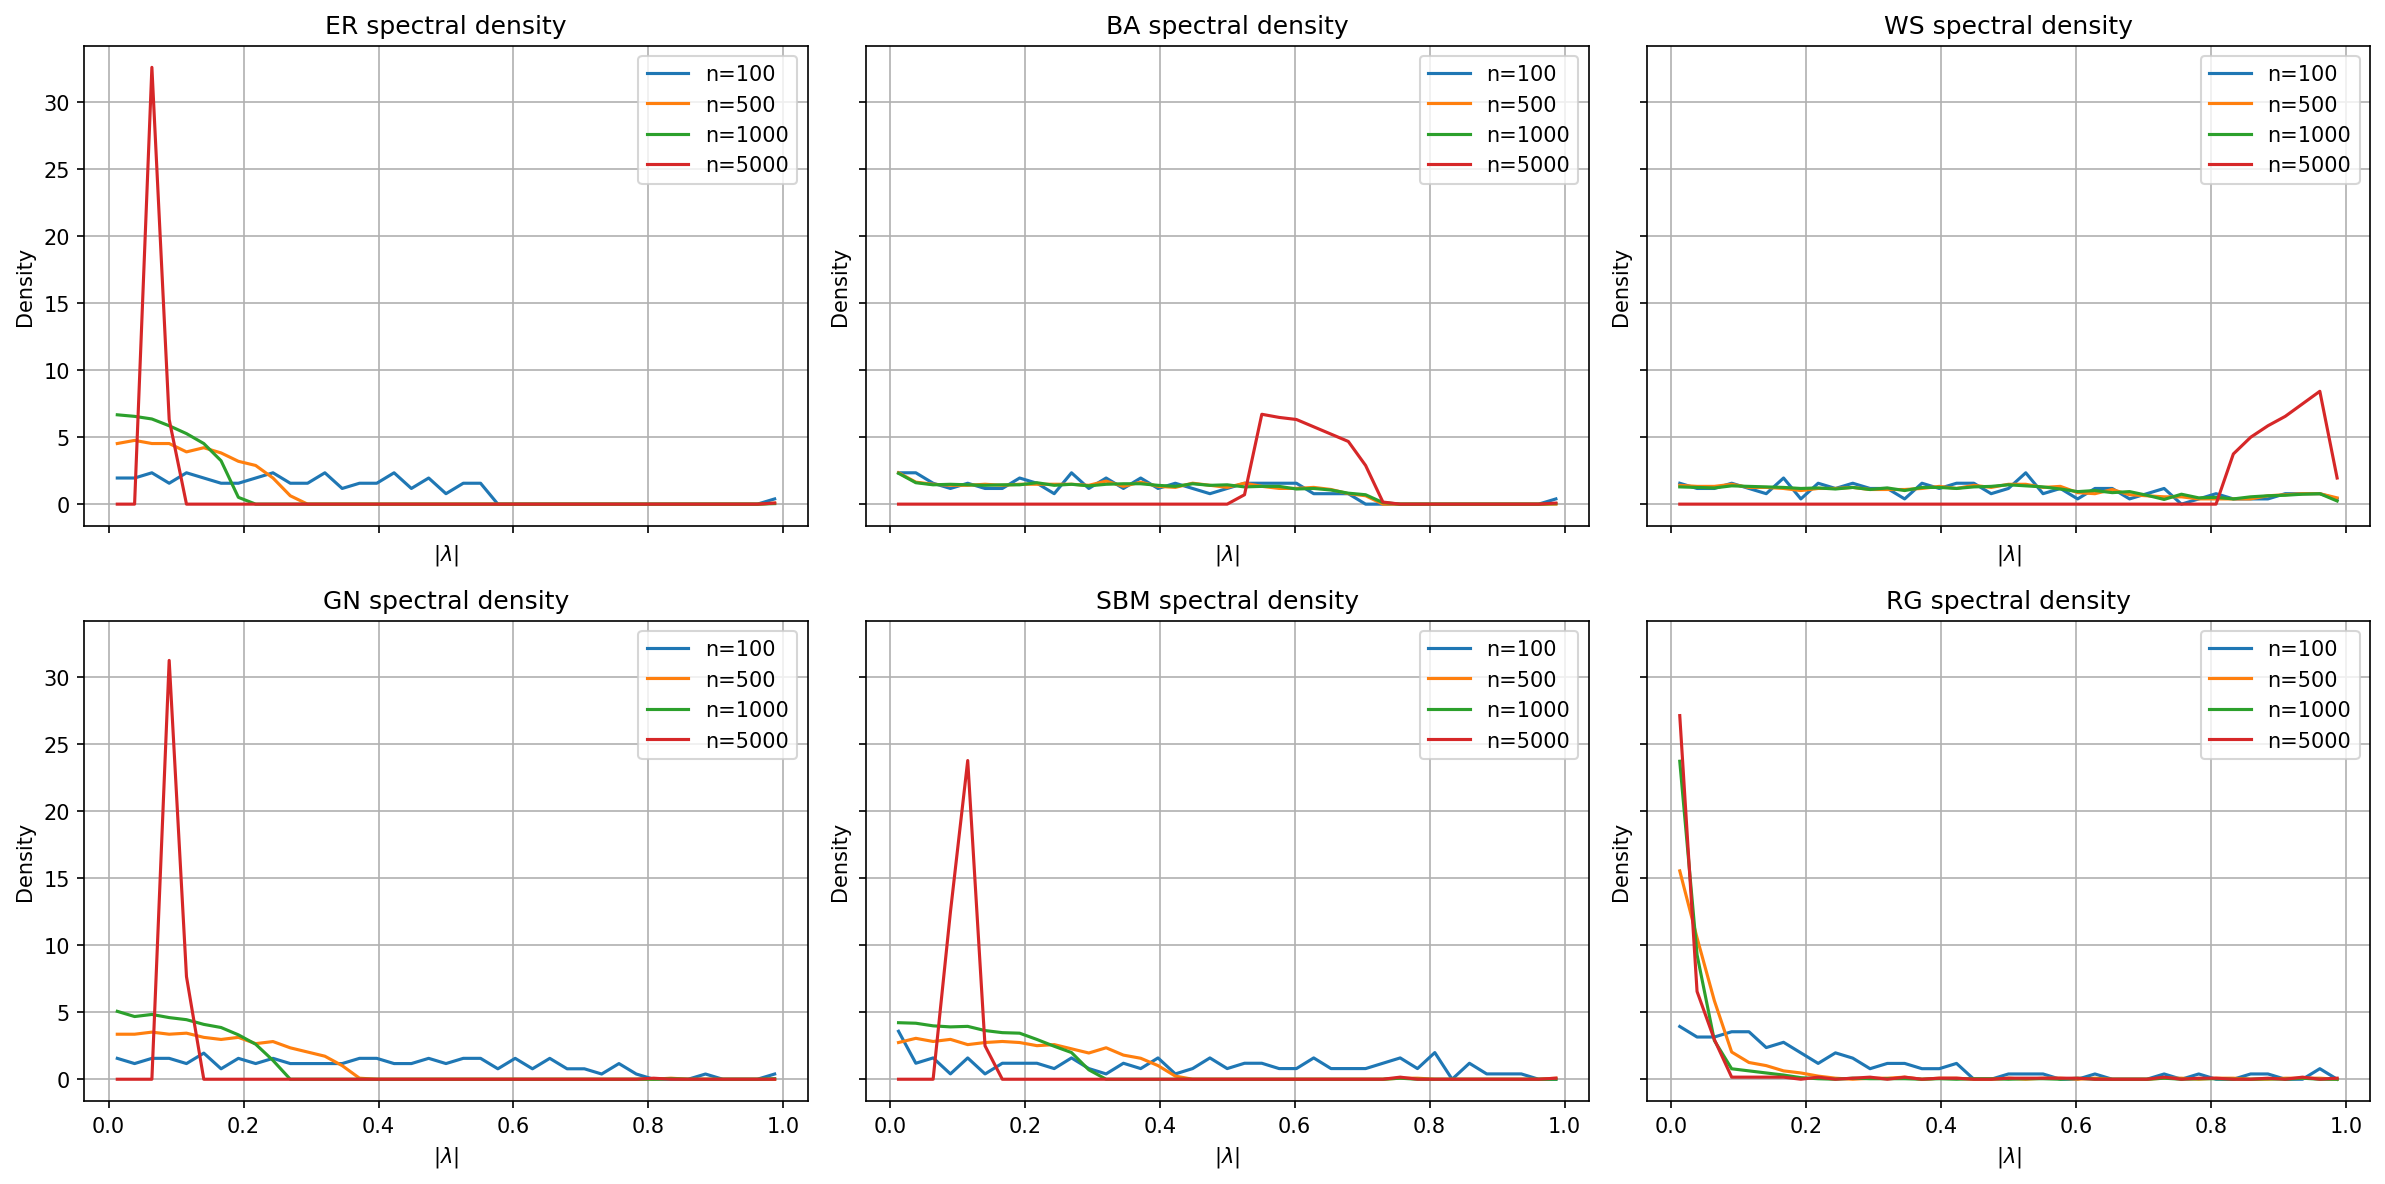

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import eigs

# spectra[ntype][size] = eigenvalues (complex) for ONE representative sample
spectra = {
    ntype: {} for ntype in network_types.keys()
}

for ntype in network_types:
    for size in sizes:
        # Use first sample as representative for density plots
        G = all_graphs[ntype][size]['sample_1']

        # Build A and D^{-1}
        A = nx.adjacency_matrix(G)           # scipy sparse matrix
        degrees = np.array([d for _, d in G.degree()],
                           dtype=float)
        # avoid division by zero for isolated nodes (if any)
        degrees[degrees == 0.0] = 1.0
        D_inv = sp.diags(1.0 / degrees)

        P = D_inv @ A                        # random-walk matrix (sparse)
        n = G.number_of_nodes()

        # Full spectrum for smaller graphs; approximate for large
        if n <= 500:
            evals = np.linalg.eigvals(P.toarray())
        else:
            # Grab many of the largest-magnitude eigenvalues to approximate density
            k = 500
            evals = eigs(P.T, k=k, which='LR',
                         return_eigenvectors=False)

        spectra[ntype][size] = evals

# ---- Plot spectral density of |λ| ----

bins = np.linspace(0, 1, 40)
n_types = len(network_types)
n_rows = 2
n_cols = int(np.ceil(n_types / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8),
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, (ntype, size_dict) in zip(axes, spectra.items()):
    for size, evals in size_dict.items():
        lam_mod = np.abs(evals)
        hist, edges = np.histogram(lam_mod, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, hist, label=f"n={size}")

    ax.set_title(f"{ntype} spectral density")
    ax.set_xlabel(r"$|\lambda|$")
    ax.set_ylabel("Density")
    ax.grid(True)
    ax.legend()

# Hide unused subplots if any
for i in range(len(spectra), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


Now, we will calculate the spectral gap (diff between the largest and second largest eigenvalues) for each network type and size, and analyze how it relates to the contagion dynamics observed in part (c).

In [18]:
# top_eigs[ntype][size][sample_key] = dict(lambda1, lambda2, gamma)
top_eigs = {
    ntype: {size: {} for size in sizes}
    for ntype in network_types.keys()
}

for ntype in network_types:
    for size in sizes:
        for sample_key, G in all_graphs[ntype][size].items():

            A = nx.adjacency_matrix(G)
            degrees = np.array([d for _, d in G.degree()], dtype=float)
            degrees[degrees == 0.0] = 1.0
            D_inv = sp.diags(1.0 / degrees)
            P = D_inv @ A

            # Use sparse eigensolver to get largest few eigenvalues in magnitude
            vals = eigs(P.T, k=5, which='LR',
                        return_eigenvectors=False)

            # Sort by magnitude descending
            vals_mod = np.sort(np.abs(vals))[::-1]
            lambda1, lambda2 = vals_mod[0], vals_mod[1]
            gamma = lambda1 - lambda2  # should be ~ 1 - lambda2

            top_eigs[ntype][size][sample_key] = {
                'lambda1': lambda1,
                'lambda2': lambda2,
                'gamma': gamma
            }

# Optional: summarize average gaps
for ntype in network_types:
    print(f"\n{ntype}:")
    for size in sizes:
        gammas = [info['gamma']
                  for info in top_eigs[ntype][size].values()]
        print(f"  n={size}: mean γ = {np.mean(gammas):.4f}, std = {np.std(gammas):.4f}")



ER:
  n=100: mean γ = 0.4423, std = 0.0110
  n=500: mean γ = 0.7381, std = 0.0016
  n=1000: mean γ = 0.8128, std = 0.0003
  n=5000: mean γ = 0.9155, std = 0.0003

BA:
  n=100: mean γ = 0.3235, std = 0.0135
  n=500: mean γ = 0.2873, std = 0.0019
  n=1000: mean γ = 0.2843, std = 0.0050
  n=5000: mean γ = 0.2777, std = 0.0009

WS:
  n=100: mean γ = 0.0305, std = 0.0085
  n=500: mean γ = 0.0160, std = 0.0032
  n=1000: mean γ = 0.0168, std = 0.0013
  n=5000: mean γ = 0.0119, std = 0.0026

GN:
  n=100: mean γ = 0.1185, std = 0.0084
  n=500: mean γ = 0.1691, std = 0.0067
  n=1000: mean γ = 0.1762, std = 0.0020
  n=5000: mean γ = 0.1807, std = 0.0009

SBM:
  n=100: mean γ = 0.0858, std = 0.0234
  n=500: mean γ = 0.2225, std = 0.0036
  n=1000: mean γ = 0.2306, std = 0.0076
  n=5000: mean γ = 0.2465, std = 0.0007

RG:
  n=100: mean γ = 0.0273, std = 0.0066
  n=500: mean γ = 0.0500, std = 0.0045
  n=1000: mean γ = 0.0545, std = 0.0032
  n=5000: mean γ = 0.0555, std = 0.0010


What did we expect?
Interpret the results

Ok so, for a random walk, the mixing time (how fast it approaches the stationary distribution) is essentially set by the second-largest eigenvalue modulus. Therefore, the spectral gap gamma (the difference between the largest and second-largest eigenvalues) which is almost equal to 1 - lambda_2 for stochastic matrices, gives us a measure of how quickly the random walk converges to its steady state.

A larger spectral gap (gamma) indicates smaller lambda2, smaller mixing time, faster mixing, and a quicker spread of the contagion. Conversely, a smaller spectral gap suggests slower mixing and a more gradual contagion spread.

What we expect in ER graphs is homogeneity, no communities, fast convergence, and, larger spectral gap.
Let's dig into all different graphs and sizes to see how they compare.

#### ER
as n grows, gamma increases, meaning faster mixing and quicker contagion spread.

#### BA
the presence of hubs + many low-degree nodes keeps lambda_2 bounded away from 0; contagion speed doesn’t improve much with bigger n.

#### WS
the WS graph is very ring-like with only a few shortcuts, leading to slow mixing and small spectral gap, regardless of size. We can see that gamma remains small (and even decreases slightly) as n increases, indicating slow mixing and gradual contagion spread.

#### GN & SBM
These graphs have strong community (by definition), leading to small spectral gaps and slow mixing. As n increases, gamma remains small, indicating that the contagion spread is gradual due to the pronounced community structure. But still, not as slow as WS.

#### RG (Random Geometric)
The RG graph has spatial constraints that limit connectivity, resulting in a small spectral gap and slow mixing. As n increases, gamma remains small (decreases slightly), indicating that the contagion spread is gradual due to the spatial structure.


Overall, the spectral gap provides valuable insights into how network structure influences contagion dynamics. Networks with larger spectral gaps facilitate faster contagion spread, while those with smaller gaps lead to more gradual spread due to slower mixing times. It's fascinating to see how different network topologies impact the spectral properties and, consequently, the dynamics of contagion processes! :D

## Thresholds, Heterogeneity, and Adoption Dynamics

**Outline:**
- Individual adoption thresholds
- Heterogeneous populations
- Impact on contagion dynamics

**Introduction:**
In real social systems, individuals differ in their willingness to adopt new ideas or behaviors. This section explores how varying thresholds and heterogeneity affect the spread of contagion, revealing richer and more realistic dynamics than uniform models.

**Motivation:**
Understanding threshold effects helps explain why some ideas fail to spread while others go viral, and how diversity in populations can stabilize or destabilize contagion.

Relevant Book:
The tipping point, by Malcolm Gladwell (2000).
https://www.amazon.com/Tipping-Point-Little-Things-Difference/dp/0316346624

## Other Extensions and Advanced Topics:

There are several advanced topics and underexplored areas in the study of social contagion that we will **not** fully develop in this notebook, but that are worth knowing about:

- **Higher-order (simplicial) contagion**  
  Contagion can depend on *groups* of neighbors (triangles, cliques) rather than individual edges.  
  See Iacopini et al. (2019), *Simplicial models of social contagion*.

- **Emergent directionality and effective flow**  
  Even on undirected graphs, complex contagion can produce *directional* flow of influence due to asymmetries in thresholds and structure.  
  See the preprint *Emergent Directedness in Social Contagion* (2025).

- **Competing contagions and interference**  
  Multiple behaviors / ideas / pathogens may spread simultaneously and compete for attention or “slots” (time, money, social identity).  
  We provide a short supplementary code example below; a full treatment would require more modeling choices.

- **Contagion beyond static networks**  
  Spatial models, agent-based models, temporal networks, and hybrid frameworks can capture changing contact patterns and mobility.

- **Contagion in LLMs and algorithmic systems**  
  Large language models and recommender systems can amplify and channel contagion-like dynamics in human populations and online platforms.



### Contagion on Directed/Weighted Networks

**Outline:**
- Directionality and edge weights
- Impact on contagion
- Visualization and analysis

**Introduction:**
Not all connections are equal—some are stronger, and some have direction. This section explores how directed and weighted edges change the dynamics of contagion.

**Motivation:**
Accounting for direction and weight is essential for modeling influence, trust, and information flow in real networks.

### Contagion Beyond Networks: Spatial, Agent-Based, and Hybrid Models

**Outline:**
- Spatial grids and agent-based models
- Hybrid approaches
- Comparison with network-based contagion

**Introduction:**
Contagion can also be modeled in spatial and agent-based frameworks, capturing local interactions and movement. This section introduces these models and compares them to network-based approaches.

**Motivation:**
Spatial and agent-based models provide deeper insight into phenomena like disease spread, crowd behavior, and innovation diffusion.


### Advanced Visualization and Animation

**Outline:**
- Interactive widgets and animations
- Real-time and step-by-step visualizations
- GIF creation

**Introduction:**
Visualizing contagion dynamically brings models to life. This section introduces advanced visualization tools and techniques for interactive and animated exploration.

**Motivation:**
Animations and interactivity enhance understanding and engagement, making complex processes intuitive.


### Social Contagion in LLMs

**Outline:**
- LLMs as agents in social networks
- Contagion of ideas, behaviors, and memes in LLM societies
- Simulation and analysis of propagation dynamics

**Introduction:**
Large Language Models (LLMs) can act as agents in digital societies, propagating information, behaviors, and even biases. This section explores how social contagion manifests in networks of LLMs, including emergent phenomena and feedback loops.

**Motivation:**
Understanding contagion in LLM agent societies is crucial for designing robust, ethical, and interpretable AI systems, and for anticipating unintended consequences in large-scale deployments.


### Causal Identification: Contagion vs Homophily

**Outline:**
- Distinguishing contagion from homophily
- Experimental and statistical approaches
- Implications for inference and policy

**Introduction:**
Observed correlations in networks may arise from contagion (influence) or homophily (similarity). This section discusses methods to disentangle these effects and the challenges involved.

**Motivation:**
Causal identification is essential for valid inference and effective intervention in social systems.


## Influence Maximization and Seeding Strategies

**Outline:**
- Selecting optimal seed nodes
- Greedy and heuristic algorithms
- Comparison of outcomes

**Introduction:**
Influence maximization seeks to identify the best nodes to initiate contagion for maximum spread. This section introduces key algorithms and compares their effectiveness in different networks.

**Motivation:**
Optimizing seed selection is vital for viral marketing, information campaigns, and epidemic control.



## References
- Milgram, S. (1967). *The small-world problem*. Psychology Today.  
- Watts, D. J., & Strogatz, S. H. (1998). *Collective dynamics of ‘small-world’ networks*. Nature.  
- Newman, M. E. J. (2002–2010). *Random graphs & networks; percolation & epidemics on networks*, in various papers and book chapters.  
- Pastor-Satorras, R., Castellano, C., Van Mieghem, P., & Vespignani, A. (2015). *Epidemic processes in complex networks*. Rev. Mod. Phys.  
- Kempe, D., Kleinberg, J., & Tardos, É. (2003). *Maximizing the spread of influence through a social network*. KDD.  
- Watts, D. J. (2002). *A simple model of global cascades on random networks*. PNAS.  
- Centola, D., & Macy, M. (2007). *Complex contagions and the weakness of long ties*. AJS.  
- Centola, D. (2010). *The spread of behavior in an online social network experiment*. Science.  
- Christakis, N. A., & Fowler, J. H. (2007–2013). Social contagion in health and behavior.
- Gleeson, J.P. & Cahalane, D.J. (2007); Gleeson (2008). *Cascades on random networks*. 
- Pastor-Satorras, R., Castellano, C., Van Mieghem, P., & Vespignani, A. (2015). *Epidemic processes in complex networks*. Rev. Mod. Phys.
- Granovetter, M. (1978). *Threshold models of collective behavior*. AJS.
- Dodds, P. S., & Watts, D. J. (2004). *Universal behavior in a generalized model of contagion*. Physical Review Letters.
- Christakis, N. A., & Fowler, J. H. (2013). *Social contagion theory: examining dynamic social networks and human behavior*. Statistics in medicine, 32(4), 556-577.
- Hodas, N. O., & Lerman, K. (2014). *The simple rules of social contagion*. Scientific reports, 4(1), 4343.
- Ugander, J., Backstrom, L., Marlow, C., & Kleinberg, J. (2012). *Structural diversity in social contagion*. Proceedings of the national academy of sciences, 109(16), 5962-5966.
- Gladwell, M. (2000). *The Tipping Point: How Little Things Can Make a Big Difference*. Little, Brown.
- Konstantinou, P., Georgiou, K., Kumar, N., Kyprianidou, M., Nicolaides, C., Karekla, M., & Kassianos, A. P. (2021). *Transmission of vaccination attitudes and uptake based on social contagion theory: a scoping review*. Vaccines, 9(6), 607.
- Airoldi, E. M., & Christakis, N. A. (2024). *Induction of social contagion for diverse outcomes in structured experiments in isolated villages*. Science, 384(6695), eadi5147.
- Centola, D. (2018). *How behavior spreads: The science of complex contagions*. Princeton University Press.
- Nalipay, M. J. N., King, R. B., & Cai, Y. (2024). *Happy teachers make happy students: The social contagion of well-being from teachers to their students*. School Mental Health, 16(4), 1223-1235.
- Platek, S. M., Mohamed, F. B., & Gallup Jr, G. G. (2005). *Contagious yawning and the brain*. Cognitive brain research, 23(2-3), 448-452.
- Fowler, J. H., & Christakis, N. A. (2008). *Dynamic spread of happiness in a large social network: longitudinal analysis over 20 years in the Framingham Heart Study*. BMJ, 337.
- Iacopini, I., Petri, G., Barrat, A., & Latora, V. (2019). *Simplicial models of social contagion*. Nature Communications, 10, 2485.
- [Preprint] *Emergent Directedness in Social Contagion* (2025). arXiv:2510.06012.


## Useful Links

- Network Repository: https://networkrepository.com/
- Six Degrees of Separation (Verbatism): https://www.youtube.com/watch?v=CYlon2tvywA

## Supplementary Materials: Competing Contagions and Interference

**Outline:**
- Multiple ideas/memes/behaviors
- Competition, suppression, coexistence
- Visualization of outcomes

**Introduction:**
In many settings, several ideas or behaviors compete for adoption. This section models competing contagions, showing how interference and suppression can shape the final outcome.

**Motivation:**
Understanding competition is crucial for marketing, public health, and information warfare, where multiple influences vie for attention.


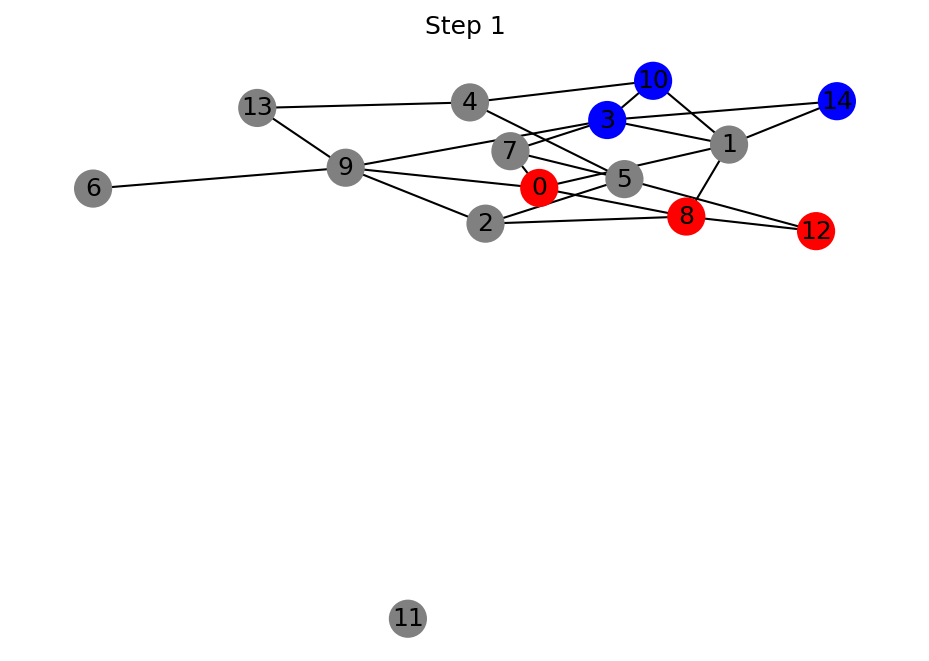

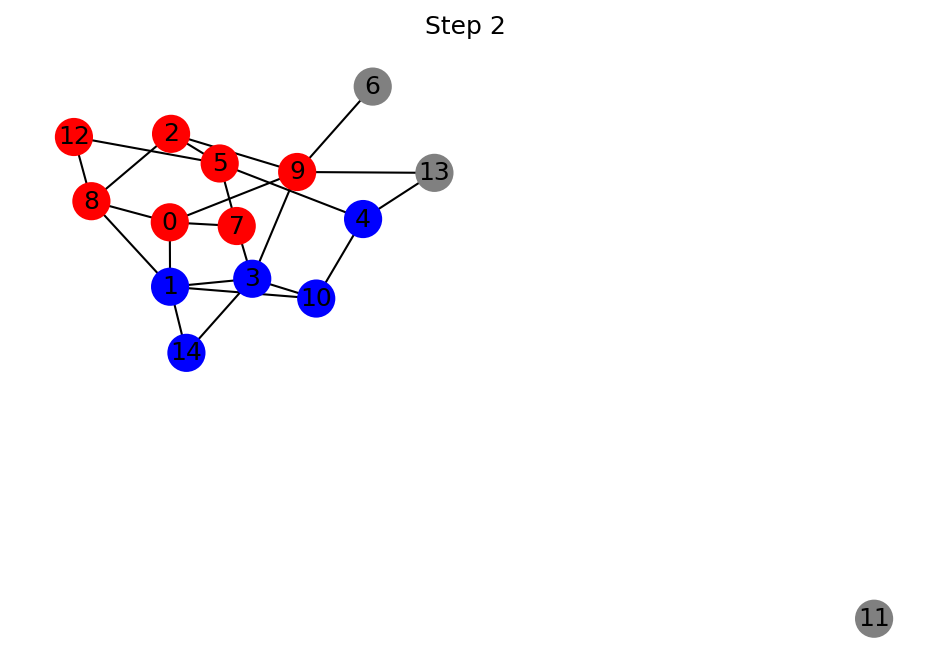

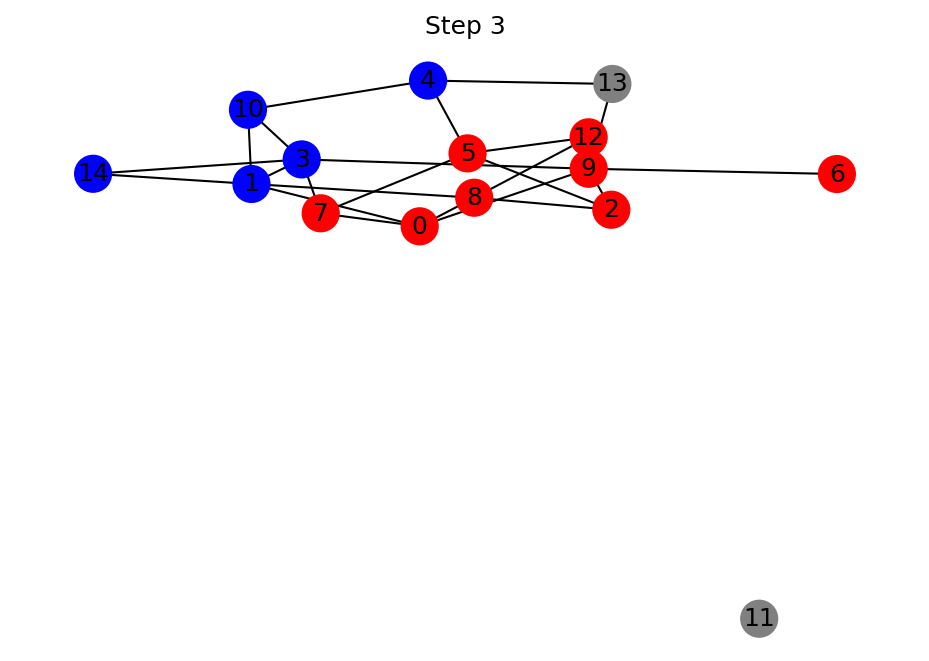

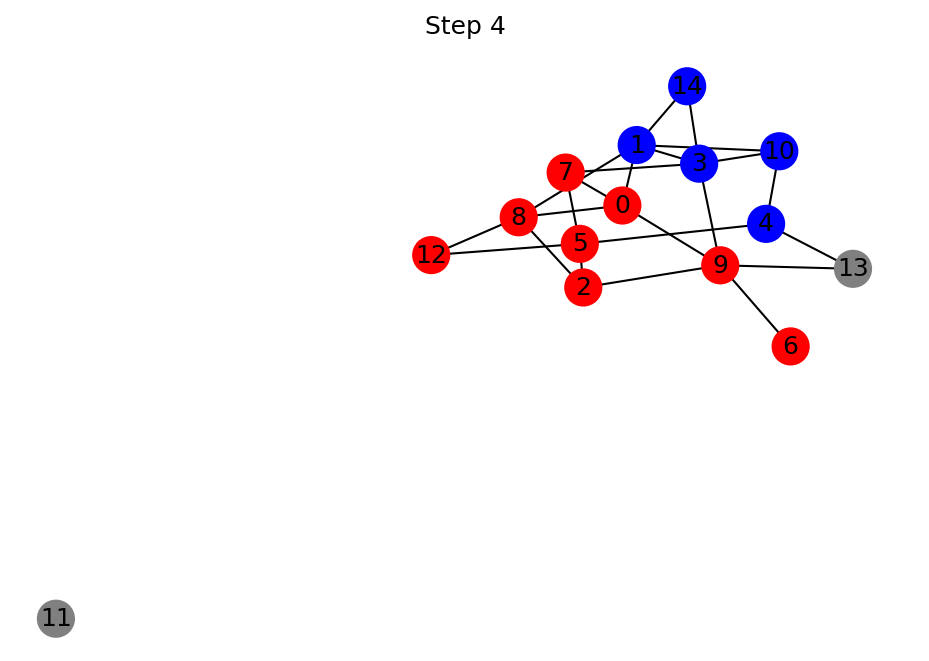

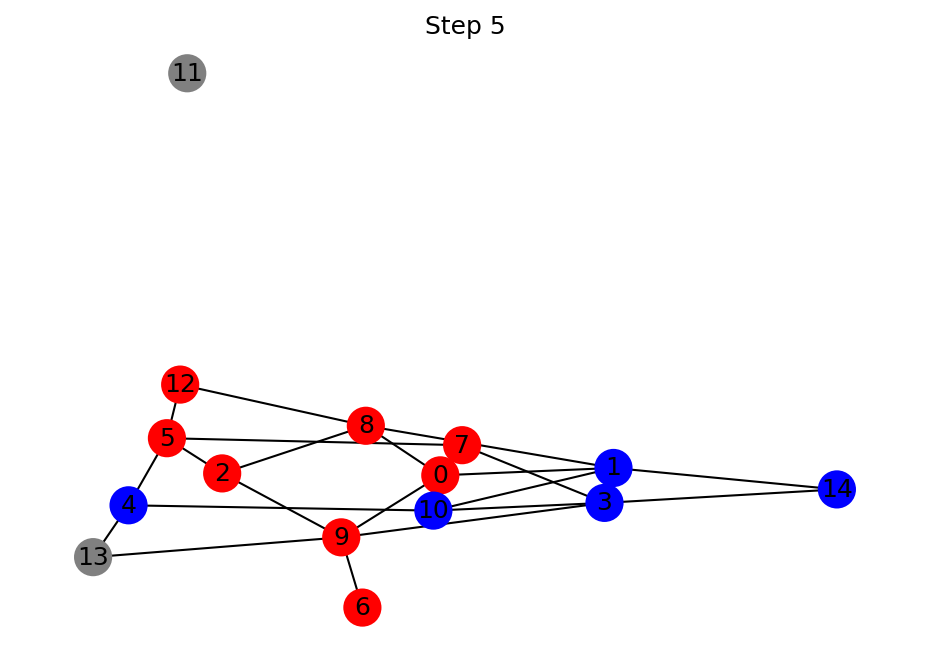

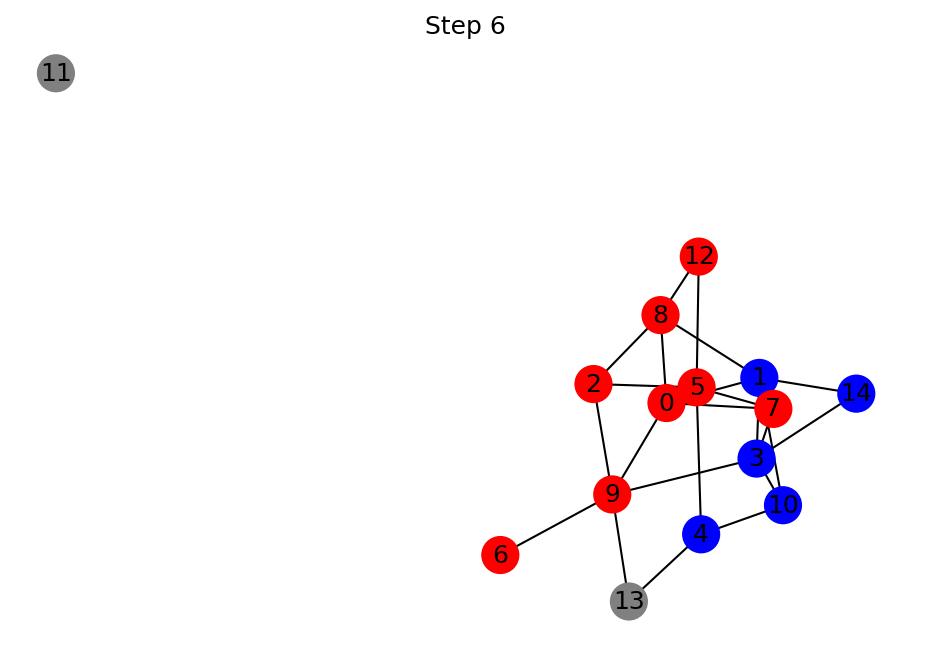

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

G = nx.erdos_renyi_graph(15, 0.2)
state = np.zeros(G.number_of_nodes(), dtype=int)  # 0: susceptible, 1: A, 2: B
state[0] = 1  # seed A
state[-1] = 2  # seed B

for step in range(6):
    for node in G.nodes():
        if state[node] == 0:
            neighbors = list(G.neighbors(node))
            neighbor_states = [state[n] for n in neighbors]
            if neighbor_states.count(1) > neighbor_states.count(2):
                state[node] = 1
            elif neighbor_states.count(2) > neighbor_states.count(1):
                state[node] = 2
    colors = ['gray' if s==0 else 'red' if s==1 else 'blue' for s in state]
    nx.draw(G, node_color=colors, with_labels=True)
    plt.title(f'Step {step+1}')
    plt.show()